# Stockholm Statistikomraden (RegSO) - Analys & Visualisering

Data fran SCB for aren 2021-2024, med matplotlib-grafer och DuckDB SQL-analyser.

**OBS:** RegSO (Regionala statistikomraden) ar SCB:s geografiska indelning for statistik.  
Detta ar INTE samma som Stockholms stads administrativa stadsdelsnamnder.

- **127 RegSO-omraden** i Stockholms kommun
- **14 stadsdelsnamnder** (administrativa enheter)
- RegSO ar finare uppdelning och liknar "stadsdelar i folkmun"

---

## Datakallor

| Tabell | Innehall | Niva | Tidsperiod |
|--------|----------|------|------------|
| TAB6574 | Folkmängd per åldersgrupp | RegSO (Stockholm) | 2021-2024 |
| TAB6568 | Hushållstyper | RegSO (Stockholm) | 2021-2024 |
| TAB6638 | Upplåtelseformer | RegSO (Stockholm) | 2024 (enda tillgängliga) |
| TAB2017 | Kommunala skattesatser | Kommunnivå (hela Sverige) | Senaste år |
| TAB6586 | Socioekonomiska indikatorer | RegSO (hela Sverige) | Senaste år |
| TAB3554 | Medelinkomst och medianinkomst | Kommunnivå (hela Sverige) | 2021-2024 (filtreras mot AR) |
| BO0406Tab02 | Hyror per kvm i hyreslägenheter | Stadsdelsområde (Stockholm) | 2016-2025 (filtreras mot AR) |

---

## Workflow

1. **Hämta RAW data** - All detalj per tillgängligt år per tabell
2. **Exportera RAW** - Spara detaljerad data till CSV
3. **Aggregera** - Kombinera och beräkna nyckeltal (snapshot senaste år)
4. **Analysera** - SQL-queries med DuckDB och visualiseringar med matplotlib
5. **Exportera aggregerad** - Färdig data för dashboard och vidare analys

---

## Tekniska noter

- **API-format:** SCB:s API v2 använder GET med URL-parametrar (inte POST med JSON body)
- **Batch-strategi:** Max 50 kommuner / 10 RegSO-områden per request
- **Tillgängliga år:** Filtreras dynamiskt per tabell
- **URL-encoding:** Specialtecken som + encodas till %2B i URL-parametrar
- **DuckDB:** Kolumnnamn med komma eller mellanslag omsluts med "..." i SQL
- **Hyrestabellen:** Använder separat API-endpoint (api.scb.se) och POST med JSON payload

---
## Setup & Konfiguration

Importerar bibliotek, sätter sökvägar och konfigurerar SCB API-anslutningen.

In [5]:
# IMPORTS & KONFIGURATION

import requests
import pandas as pd
import itertools
import matplotlib.pyplot as plt
import matplotlib as mpl
import duckdb
import numpy as np
from pathlib import Path

plt.style.use('seaborn-v0_8-darkgrid')
mpl.rcParams['figure.figsize'] = (12, 6)
mpl.rcParams['font.size'] = 10

BASE_DIR   = Path.cwd()
DATA_DIR   = BASE_DIR.parent / "data_files"
OUTPUT_DIR = BASE_DIR / "outputs"
DATA_DIR.mkdir(exist_ok=True, parents=True)
OUTPUT_DIR.mkdir(exist_ok=True, parents=True)

BASE_URL = "https://statistikdatabasen.scb.se/api/v2"
LANG     = "sv"

TABLE_FOLKM_DESO = "TAB6574"
TABLE_HUSHALL    = "TAB6568"
TABLE_BOENDE     = "TAB6638"
TABLE_SKATT      = "TAB2017"
TABLE_SOCIO      = "TAB6586"
TABLE_INKOMST    = "TAB3554"

# Tidsperiod for RegSO-tabeller. Filtreras mot tillgangliga ar per tabell.
# Skatt/socio hamtar senaste ar automatiskt. Inkomst (TAB3554) foljer AR.
AR       = ["2021", "2022", "2023", "2024"]
AR_LABEL = f"{AR[0]}_{AR[-1]}"

BATCH_SIZE = 10

print("Bibliotek importerade")
print(f"  DATA_DIR   : {DATA_DIR}")
print(f"  OUTPUT_DIR : {OUTPUT_DIR}")

Bibliotek importerade
  DATA_DIR   : c:\Users\chris\Documents\github\UrbanPulse\data_files
  OUTPUT_DIR : c:\Users\chris\Documents\github\UrbanPulse\EDA\outputs


---
## Hjälpfunktioner

Fyra hjälpfunktioner hanterar all kommunikation med SCB:s API:

- **`get_metadata(table_id)`** – Hämtar tabellstruktur och tillgängliga värden
- **`stockholm_regso_koder(meta)`** – Filtrerar ut Stockholms 127 RegSO-koder
- **`jsonstat2_to_df(data, region_namn_map)`** – Konverterar API-svar till DataFrame
- **`fetch_batch(table_id, regso_map, extra_filters)`** – Hämtar RegSO-data i batchar

In [6]:
# ═══════════════════════════════════════════════════════════════════════════
# HJÄLPFUNKTIONER FÖR SCB API
# ═══════════════════════════════════════════════════════════════════════════

def get_metadata(table_id):
    """Hämta metadata från SCB API för en tabell.
    
    Metadata innehåller information om:
    - Vilka dimensioner som finns (Region, Ålder, Kön, etc.)
    - Vilka värden varje dimension kan ha
    - Labels/namn för alla värden
    
    Används av alla datasektioner för att dynamiskt hämta koder och labels
    utan hårdkodning – gör koden robust mot SCB:s uppdateringar.
    
    Args:
        table_id (str): SCB tabellnummer, ex. 'TAB6574'
        
    Returns:
        dict: JSON med tabellstruktur och alla möjliga värden
        
    Exempel:
        >>> meta = get_metadata('TAB6574')
        >>> meta['dimension']['Alder']['category']['label']
        {'0-4': '0-4 år', '5-9': '5-9 år', ...}
    """
    url = f"{BASE_URL}/tables/{table_id}/metadata?lang={LANG}"
    r = requests.get(url)
    r.raise_for_status()  # Kastar exception vid HTTP-fel (404, 500, etc.)
    return r.json()


def stockholm_regso_koder(meta):
    """Filtrera ut RegSO-koder för Stockholm från metadata.
    
    SCB:s tabeller innehåller data för hela Sverige. Denna funktion
    plockar ut bara de 127 RegSO-områdena i Stockholms kommun.
    
    RegSO-koder ser ut så här: '0180R001_RegSO2025'
    - '0180'       = Stockholms kommunkod
    - 'R001'       = Regionalt statistikområde nummer 1
    - '_RegSO2025' = Suffix som indikerar RegSO-indelning för 2025
    
    Args:
        meta (dict): Metadata från get_metadata()
        
    Returns:
        dict: {region_kod: områdesnamn} för alla 127 områden
              Ex: {'0180R001_RegSO2025': 'Stockholm (Abrahamsberg)'}
    """
    region_cats   = meta["dimension"]["Region"]["category"]["index"]
    region_labels = meta["dimension"]["Region"]["category"]["label"]
    
    # Filtrera: Börjar med 0180 (Stockholm) OCH slutar med _RegSO2025
    regso = {k: region_labels[k] for k in region_cats.keys()
             if k.startswith("0180") and k.endswith("_RegSO2025")}
    return regso


def jsonstat2_to_df(data, region_namn_map):
    """Konvertera JSON-stat2 format till pandas DataFrame.
    
    SCB returnerar data i JSON-stat2-format, som är optimerat för
    nätverksöverföring men inte praktiskt för analys. Funktionen
    omvandlar till "long format" DataFrame där varje rad är en observation.
    
    OBS: Funktionen tar region_namn_map som andra argument.
    - För RegSO-tabeller: regso_map från stockholm_regso_koder()
    - För kommundata (skatt, inkomst, socio): använd {k: k for k in batch}
      vilket ger ingen namnöversättning (koden behålls som-är)
    
    Exempel på transformation:
        JSON-stat2:
          dimensions: [Region, Alder]
          values: [100, 150, 200, 250]
        
        Blir DataFrame:
          Region          Alder     value
          0180R001_...    0-4 år    100
          0180R001_...    5-9 år    150
          0180R002_...    0-4 år    200
          0180R002_...    5-9 år    250
    
    Args:
        data (dict): JSON-stat2 response från SCB API
        region_namn_map (dict): Mapping från regionkod till namn.
                                RegSO: {'0180R001_RegSO2025': 'Abrahamsberg'}
                                Kommuner: {'0180': '0180'} (ingen översättning)
        
    Returns:
        DataFrame: En rad per observation med kolumner för varje dimension,
                   'value' och 'Statistikområde' (läsbart namn)
    """
    dims   = data["id"]      # Dimensioner i ordning, ex: ['Region', 'Alder', 'Tid']
    values = data["value"]   # Värden i samma ordning som kombinationerna
    
    dim_vals = []
    for d in dims:
        if d == "Region":
            # Behåll koderna för Region (används för mappning nedan)
            dim_vals.append(list(data["dimension"][d]["category"]["index"].keys()))
        else:
            # Använd läsbara labels för övriga dimensioner
            dim_vals.append(list(data["dimension"][d]["category"]["label"].values()))
    
    # Kartesisk produkt: alla kombinationer av dimensionsvärden
    # Ex: [R1, R2] × [0-4, 5-9] = [(R1,0-4), (R1,5-9), (R2,0-4), (R2,5-9)]
    df = pd.DataFrame(list(itertools.product(*dim_vals)), columns=dims)
    df["value"] = values
    
    # Städa områdesnamn: "Stockholm (Abrahamsberg)" → "Abrahamsberg"
    df["Statistikområde"] = df["Region"].map(
        lambda x: region_namn_map.get(x, x).replace("Stockholm (", "").replace(")", "")
    )
    
    # Flytta Statistikområde till andra kolumnen för läsbarhet
    cols = df.columns.tolist()
    cols.insert(1, cols.pop(cols.index("Statistikområde")))
    return df[cols]


def fetch_batch(table_id, regso_map, extra_filters):
    """Hämta data från SCB API i batchar – för RegSO-tabeller.
    
    SCB:s API har begränsningar på requeststorlek. Funktionen delar upp
    hämtningen i batchar om BATCH_SIZE (10) RegSO-områden åt gången.
    
    OBS: Denna funktion är avsedd för RegSO-tabeller med långa koder
    ('0180R001_RegSO2025'). För rikstäckande kommundata (skattesatser,
    inkomst, socioekonomiska indikatorer) används direkta GET-anrop med
    batch_map = {k: k for k in batch} istället för regso_map.
    
    Varför batchar?
    - 127 områden × 17 åldersgrupper = 2159 datapunkter
    - Stora requests kan ge timeout eller serverproblem
    - Lösning: 10 områden åt gången = 13 requests totalt
    
    Args:
        table_id (str): SCB tabellnummer, ex. 'TAB6574'
        regso_map (dict): {regionkod: namn} från stockholm_regso_koder()
        extra_filters (dict): Filter för andra dimensioner än Region.
                             Specialtecken (+) URL-encodas automatiskt till %2B.
                             Ex: {'Alder': ['0-4', '5-9'], 'Tid': ['2024']}
        
    Returns:
        DataFrame eller None: Sammanslagna data från alla lyckade batchar,
                             eller None om samtliga batchar misslyckades.
        
    Exempel:
        >>> meta = get_metadata('TAB6574')
        >>> regso = stockholm_regso_koder(meta)
        >>> df = fetch_batch('TAB6574', regso, {
        ...     'Alder': ['0-4', '5-9'],
        ...     'Tid': ['2024']
        ... })
        Hämtar 127 områden i 13 batcher...
          ✓ 5/13 batcher klara
        ✅ Klart – 254 rader
    """
    koder   = list(regso_map.keys())
    batches = [koder[i:i + BATCH_SIZE] for i in range(0, len(koder), BATCH_SIZE)]
    print(f"Hämtar {len(koder)} områden i {len(batches)} batcher...")
    
    dfs = []
    
    for i, batch in enumerate(batches, 1):
        params = [
            f"lang={LANG}",
            "outputFormat=JSON-stat2",
            f"valueCodes[Region]={','.join(batch)}",
        ]
        
        for dim, vals in extra_filters.items():
            # + måste URL-encodas till %2B (ex: "1+2" → "1%2B2")
            encoded_vals = [v.replace("+", "%2B") for v in vals]
            params.append(f"valueCodes[{dim}]={','.join(encoded_vals)}")
        
        url = f"{BASE_URL}/tables/{table_id}/data?" + "&".join(params)
        
        try:
            r = requests.get(url, timeout=15)
            if r.status_code == 200:
                df = jsonstat2_to_df(r.json(), regso_map)
                dfs.append(df)
            else:
                print(f"  ⚠️  Batch {i}: HTTP {r.status_code}")
        except Exception as e:
            print(f"  ⚠️  Batch {i}: {str(e)[:100]}")
        
        if i % 5 == 0:
            print(f"  ✓ {i}/{len(batches)} batcher klara")
    
    if not dfs:
        return None
    
    result = pd.concat(dfs, ignore_index=True)
    print(f"✅ Klart – {len(result)} rader")
    return result

print("✓ Funktioner laddade")

✓ Funktioner laddade


---
## 1. FOLKMÄNGD MED ALLA ÅLDERSGRUPPER

**Viktigt:** Vi hämtar ALLA 17 åldersgrupper, inte bara totalsumman.

Detta ger oss:
- Detaljerad åldersstruktur per område
- Möjlighet att analysera barnfamiljer, unga vuxna, pensionärer
- Flexibilitet att skapa egna ålderskategorier

**Resultat:** 127 områden × 17 åldersgrupper = 2159 rader

In [7]:
print("\n" + "="*60)
print("FOLKMÄNGD MED ÅLDERSGRUPPER")
print("="*60)

meta_folkm  = get_metadata(TABLE_FOLKM_DESO)
regso_folkm = stockholm_regso_koder(meta_folkm)
print(f"  {len(regso_folkm)} RegSO-områden hittade")

alder_cats    = meta_folkm["dimension"]["Alder"]["category"]["index"]
aldersgrupper = [k for k in alder_cats.keys() if k != 'totalt']

ar_folkm_tillgangliga = list(meta_folkm["dimension"]["Tid"]["category"]["label"].keys())
ar_folkm       = [a for a in AR if a in ar_folkm_tillgangliga]
ar_folkm_label = f"{ar_folkm[0]}_{ar_folkm[-1]}"

print(f"  Begärda år: {AR}  Hamtar: {ar_folkm}")
print(f"  {len(aldersgrupper)} åldersgrupper x {len(ar_folkm)} år")

df_folkm = fetch_batch(TABLE_FOLKM_DESO, regso_folkm, {
    "Alder":        aldersgrupper,
    "Kon":          ["1+2"],
    "ContentsCode": ["000007Y7"],
    "Tid":          ar_folkm,
})

print(f"\nResultat:")
print(f"   {len(df_folkm)} rader ({len(regso_folkm)} områden x {len(aldersgrupper)} åldersgrupper x {len(ar_folkm)} år)")
print(f"   År i data: {sorted(df_folkm['Tid'].unique())}")


FOLKMÄNGD MED ÅLDERSGRUPPER
  127 RegSO-områden hittade
  Begärda år: ['2021', '2022', '2023', '2024']  Hamtar: ['2021', '2022', '2023', '2024']
  17 åldersgrupper x 4 år
Hämtar 127 områden i 13 batcher...
  ✓ 5/13 batcher klara
  ✓ 10/13 batcher klara
✅ Klart – 8636 rader

Resultat:
   8636 rader (127 områden x 17 åldersgrupper x 4 år)
   År i data: ['2021', '2022', '2023', '2024']


---
## 2. HUSHÅLL MED ALLA HUSHÅLLSTYPER

**Viktigt:** Vi hämtar ALLA hushållstyper, inte bara totalsumman.

Hushållstyper inkluderar:
- sammanboende med barn
- sammanboende utan barn
- ensamstående med barn
- ensamstående utan barn
- övriga hushåll
- **totalt antal hushåll** (summan av ovanstående)

**OBS:** När vi senare ska beräkna "totalt hushåll per område" använder vi BARA
raden "totalt antal hushåll", inte summan av alla rader (det skulle dubbelräkna).

**Resultat:** 127 områden × ~6 hushållstyper = ~762 rader

In [8]:
print("\n" + "="*60)
print("HUSHÅLL MED ALLA TYPER")
print("="*60)

meta_hushall  = get_metadata(TABLE_HUSHALL)
regso_hushall = stockholm_regso_koder(meta_hushall)
print(f"  {len(regso_hushall)} RegSO-områden hittade")

hushall_cats = meta_hushall["dimension"]["Hushallstyp"]["category"]["index"]

ar_hushall_tillgangliga = list(meta_hushall["dimension"]["Tid"]["category"]["label"].keys())
ar_hushall       = [a for a in AR if a in ar_hushall_tillgangliga]
ar_hushall_label = f"{ar_hushall[0]}_{ar_hushall[-1]}"

print(f"  Begärda år: {AR}  Hamtar: {ar_hushall}")
print(f"  {len(hushall_cats)} hushållstyper x {len(ar_hushall)} år")

df_hushall = fetch_batch(TABLE_HUSHALL, regso_hushall, {
    "Hushallstyp":  list(hushall_cats.keys()),
    "ContentsCode": ["000007Y1"],
    "Tid":          ar_hushall,
})

print(f"\nResultat:")
print(f"   {len(df_hushall)} rader")
print(f"   År i data: {sorted(df_hushall['Tid'].unique())}")


HUSHÅLL MED ALLA TYPER
  127 RegSO-områden hittade
  Begärda år: ['2021', '2022', '2023', '2024']  Hamtar: ['2021', '2022', '2023', '2024']
  6 hushållstyper x 4 år
Hämtar 127 områden i 13 batcher...
  ✓ 5/13 batcher klara
  ✓ 10/13 batcher klara
✅ Klart – 3048 rader

Resultat:
   3048 rader
   År i data: ['2021', '2022', '2023', '2024']


---
## 3. BOENDE MED ALLA UPPLÅTELSEFORMER

Upplåtelseformer:
- **hyresrätt** - Hyr av fastighetsägare
- **bostadsrätt** - Medlem i bostadsrättsförening
- **äganderätt** - Äger fastigheten (villa/radhus)
- **uppgift saknas** - Okänd upplåtelseform

**Resultat:** 127 områden × 4 former = 508 rader

In [9]:
print("\n" + "="*60)
print("BOENDE MED ALLA UPPLÅTELSEFORMER")
print("="*60)

meta_boende  = get_metadata(TABLE_BOENDE)
regso_boende = stockholm_regso_koder(meta_boende)
print(f"  {len(regso_boende)} RegSO-områden hittade")

boende_cats = meta_boende["dimension"]["Upplatelseform"]["category"]["index"]

# TAB6638 tillhandahaller bara 2024 (inga historiska data)
ar_boende_tillgangliga = list(meta_boende["dimension"]["Tid"]["category"]["label"].keys())
ar_boende       = [a for a in AR if a in ar_boende_tillgangliga]
ar_boende_label = f"{ar_boende[0]}_{ar_boende[-1]}"

print(f"  Begärda år: {AR}  Hamtar: {ar_boende}")
print(f"  OBS: TAB6638 har bara {ar_boende_tillgangliga}")
print(f"  {len(boende_cats)} upplåtelseformer x {len(ar_boende)} år")

df_boende = fetch_batch(TABLE_BOENDE, regso_boende, {
    "Upplatelseform": list(boende_cats.keys()),
    "ContentsCode":   ["00000864"],
    "Tid":            ar_boende,
})

print(f"\nResultat:")
print(f"   {len(df_boende)} rader")
print(f"   År i data: {sorted(df_boende['Tid'].unique())}")


BOENDE MED ALLA UPPLÅTELSEFORMER
  127 RegSO-områden hittade
  Begärda år: ['2021', '2022', '2023', '2024']  Hamtar: ['2024']
  OBS: TAB6638 har bara ['2024', '2025']
  4 upplåtelseformer x 1 år
Hämtar 127 områden i 13 batcher...
  ✓ 5/13 batcher klara
  ✓ 10/13 batcher klara
✅ Klart – 508 rader

Resultat:
   508 rader
   År i data: ['2024']


---
## EXPORT RAW DATA

Här exporterar vi den råa datan med ALLA detaljer:
- Folkmängd: En rad per område per åldersgrupp
- Hushåll: En rad per område per hushållstyp
- Boende: En rad per område per upplåtelseform

Dessa filer är bra för:
- Detaljerad analys
- Time-series (om man kör för flera år)
- Custom aggregeringar

In [10]:
print("\n" + "="*60)
print("EXPORT RAW DATA")
print("="*60)

df_folkm.to_csv(DATA_DIR / f"stockholm_folkm_regso_{ar_folkm_label}.csv", index=False)
print(f"  stockholm_folkm_regso_{ar_folkm_label}.csv ({len(df_folkm)} rader)")

df_hushall.to_csv(DATA_DIR / f"stockholm_hushall_regso_{ar_hushall_label}.csv", index=False)
print(f"  stockholm_hushall_regso_{ar_hushall_label}.csv ({len(df_hushall)} rader)")

boende_filnamn = ar_boende[0] if len(ar_boende) == 1 else ar_boende_label
df_boende.to_csv(DATA_DIR / f"stockholm_boende_regso_{boende_filnamn}.csv", index=False)
print(f"  stockholm_boende_regso_{boende_filnamn}.csv ({len(df_boende)} rader)")
print(f"  OBS: TAB6638 har bara {ar_boende}")


EXPORT RAW DATA
  stockholm_folkm_regso_2021_2024.csv (8636 rader)
  stockholm_hushall_regso_2021_2024.csv (3048 rader)
  stockholm_boende_regso_2024.csv (508 rader)
  OBS: TAB6638 har bara ['2024']


---
## AGGREGERAD DATA - För analys

Nu kombinerar vi data från flera tabeller till ett dataset med **ett område per rad**.

### Varför aggregera?

RAW data har flera rader per område:
- Folkmängd: 17 rader per område (en per åldersgrupp)
- Hushåll: 6 rader per område (en per hushållstyp)

Om vi JOINar dessa direkt får vi **kartesisk produkt** → 17 × 6 = 102 rader per område!

### Lösning:

**Aggregera FÖRST, sen JOIN:**
1. **Folkmängd:** Summera alla åldersgrupper → En totalbefolkning per område
2. **Hushåll:** Filtrera till "totalt antal hushåll" → Ett tal per område
3. **Boende:** Pivotera så varje upplåtelseform blir en kolumn
4. **JOIN:** Kombinera på Statistikområde → 127 rader totalt

### Nyckeltal som beräknas:
- Personer per hushåll (bör vara 1.5-2.5 i Stockholm)
- Bostäder per hushåll  
- Procentandel för varje boendeform

In [11]:
print("\n" + "="*60)
print("SKAPAR AGGREGERAD DATA")
print("="*60)

# Aggregerar pa senaste ar dar ALLA tre tabeller har data
senaste_ar_regso = ar_boende[-1]
print(f"  Aggregerar pa: {senaste_ar_regso}")

df_folkm_snap   = df_folkm[df_folkm['Tid'] == senaste_ar_regso].copy()
df_hushall_snap = df_hushall[df_hushall['Tid'] == senaste_ar_regso].copy()
df_boende_snap  = df_boende[df_boende['Tid'] == senaste_ar_regso].copy()

# 1. FOLKMÄNGD: Summera over alla aldersgrupper
folkm_totalt = df_folkm_snap.groupby('Statistikområde')['value'].sum().reset_index()
folkm_totalt.rename(columns={'value': 'Befolkning'}, inplace=True)
print(f"  Folkmängd: {len(folkm_totalt)} områden")

# 2. HUSHÅLL: Filtrera till 'totalt antal hushall'
hushall_totalt = df_hushall_snap[df_hushall_snap['Hushallstyp'] == 'totalt antal hushåll'].copy()
hushall_totalt = hushall_totalt[['Statistikområde', 'value']].rename(columns={'value': 'Hushall'})
print(f"  Hushåll: {len(hushall_totalt)} områden")

# 3. BOENDE: Pivotera
boende_pivot = df_boende_snap[df_boende_snap['Upplatelseform'] != 'uppgift saknas'].pivot_table(
    index='Statistikområde',
    columns='Upplatelseform',
    values='value',
    fill_value=0
).reset_index()
boende_cols = [c for c in boende_pivot.columns if c != 'Statistikområde']
boende_pivot['TotalBostader'] = boende_pivot[boende_cols].sum(axis=1)
print(f"  Boende: {len(boende_pivot)} områden")

# 4. KOMBINERA och berakna nyckeltal
df_aggregerad = folkm_totalt.copy()
df_aggregerad = df_aggregerad.merge(hushall_totalt, on='Statistikområde', how='left')
df_aggregerad = df_aggregerad.merge(boende_pivot, on='Statistikområde', how='left')

df_aggregerad['PersonerPerHushall'] = (df_aggregerad['Befolkning'] / df_aggregerad['Hushall']).round(2)
df_aggregerad['BostaderPerHushall'] = (df_aggregerad['TotalBostader'] / df_aggregerad['Hushall']).round(2)
for col in boende_cols:
    df_aggregerad[f'{col}_%'] = (df_aggregerad[col] / df_aggregerad['TotalBostader'] * 100).round(1)

print(f"\nAggregerad data klar: {len(df_aggregerad)} omraden, {len(df_aggregerad.columns)} variabler")


SKAPAR AGGREGERAD DATA
  Aggregerar pa: 2024
  Folkmängd: 127 områden
  Hushåll: 127 områden
  Boende: 127 områden

Aggregerad data klar: 127 omraden, 12 variabler


### Sanity check: Är Personer per Hushåll rimligt?

**Förväntat:** 1.5-2.5 personer/hushåll i Stockholm  
**Varningssignal:** Om vi ser 10+ eller 40+ betyder det att aggregeringen gick fel

In [12]:
print("\n📊 VERIFIERING - Personer per hushåll:\n")

print("Högst (topp 10):")
display(df_aggregerad.nlargest(10, 'PersonerPerHushall')[[
    'Statistikområde', 'Befolkning', 'Hushall', 'PersonerPerHushall'
]])

print("\nLägst (topp 10):")
display(df_aggregerad.nsmallest(10, 'PersonerPerHushall')[[
    'Statistikområde', 'Befolkning', 'Hushall', 'PersonerPerHushall'
]])

print(f"\nMedelvärde för Stockholm: {df_aggregerad['PersonerPerHushall'].mean():.2f} personer/hushåll")
print(f"Median: {df_aggregerad['PersonerPerHushall'].median():.2f}")
print("\n✅ Rimliga värden: 1.5-2.5")
print("⚠️  Om du ser 10+ eller 40+ har något gått fel i aggregeringen!")


📊 VERIFIERING - Personer per hushåll:

Högst (topp 10):


,Statistikområde,Befolkning,Hushall,PersonerPerHushall
33,0180R034 Herrängen,3878,1233,3.15
56,0180R057 Långsjö,3032,972,3.12
49,0180R050 Kälvesta,4566,1466,3.11
10,0180R011 Bromma kyrka,2694,869,3.10
98,0180R099 Södra Ängby,1623,540,3.01
62,0180R063 Mälarhöjden,4404,1478,2.98
75,0180R076 Rinkeby,17096,5731,2.98
71,0180R072 Nälsta,5040,1697,2.97
115,0180R116 Ålsten,3205,1080,2.97
14,0180R015 Eneby,869,300,2.90



Lägst (topp 10):


,Statistikområde,Befolkning,Hushall,PersonerPerHushall
22,0180R023 Fredhäll,5336,3513,1.52
44,0180R045 Johanneshov,6331,4145,1.53
74,0180R075 Riksby-Åkeshov,5154,3324,1.55
105,0180R106 Universitetet,4610,2916,1.58
66,0180R067 Norra Högalid,13858,8634,1.61
2,0180R003 Alvik,1488,915,1.63
114,0180R115 Åkeslund,3545,2177,1.63
53,0180R054 Lilla Essingen,4833,2899,1.67
100,0180R101 Tekniska Högskolan,6278,3723,1.69
104,0180R105 Ulvsunda Industriområde,3476,2053,1.69



Medelvärde för Stockholm: 2.16 personer/hushåll
Median: 2.09

✅ Rimliga värden: 1.5-2.5
⚠️  Om du ser 10+ eller 40+ har något gått fel i aggregeringen!


---
## EXPORT AGGREGERAD DATA

Detta är **huvud-filen** för analys och dashboard:
- Ett område per rad
- Alla nyckeltal färdigberäknade
- Redo att plotta direkt

In [13]:
df_aggregerad.to_csv(DATA_DIR / f"stockholm_aggregerad_{senaste_ar_regso}.csv", index=False)
print(f"  stockholm_aggregerad_{senaste_ar_regso}.csv ({len(df_aggregerad)} omraden)")

  stockholm_aggregerad_2024.csv (127 omraden)


---
## Stadsdelmappning

Lägger till kolumnen `stadsdelsomrade` i alla RegSO-filer så att de kan jointas
med `combined_services_for_map.csv` och `parker.csv` i Power BI.

**Hur mappningen fungerar:**
- `combined_services_for_map.csv` är en lookup-tabell med `stadsdel` → `stadsdelsomrade`
- RegSO-filerna har `Statistikområde` i formatet `0180R001 Abrahamsberg`
- Vi extraherar namnet efter mellanslaget och jointar mot combined
- Områden utanför Bromma och Hägersten-Älvsjö får NaN – det är korrekt

**Geografisk täckning:**

| Stadsdelsområde | Antal RegSO-områden |
|-----------------|---------------------|
| Bromma | 19 |
| Hägersten-Älvsjö | 15 |
| NaN (andra stadsdelar) | 93 |

In [14]:
# ======================================================================
# STADSDELMAPPNING
# ======================================================================
# Använder combined_services_for_map.csv som lookup-tabell istället för
# hårdkodade listor. Combined har redan exakt mappningen:
#   stadsdel (ex. 'Abrahamsberg') -> stadsdelsomrade (ex. 'Bromma')
#
# RegSO-filerna har Statistikområde i formatet '0180R001 Abrahamsberg'.
# Vi extraherar namnet efter mellanslaget för att matcha mot combined.
#
# OBS: combined_services_for_map.csv ligger i samma data_files-mapp.
# Filen genereras av ett separat ETL-script i UrbanPulse-projektet.

print("\n" + "="*60)
print("STADSDELMAPPNING")
print("="*60)

# Hämta lookup från combined
# combined_services_for_map.csv ligger i UrbanPulse/data_files
# DATA_DIR pekar dit redan (BASE_DIR.parent / 'data_files')
combined_path = BASE_DIR.parent / 'data_files' / 'combined_services_for_map.csv'
combined = pd.read_csv(combined_path)
lookup = (
    combined[['stadsdel', 'stadsdelsomrade']]
    .drop_duplicates()
    .dropna()
)
print(f"  Lookup: {len(lookup)} unika områden från combined_services_for_map.csv")

def lagg_till_stadsdel(df, omrade_kol):
    """Lägger till stadsdelsomrade baserat på områdeskolumnen.
    
    Extraherar namnet från format '0180R001 Abrahamsberg' -> 'Abrahamsberg'
    och jointar mot lookup-tabellen.
    """
    df = df.copy()
    # Ta bort gammal stadsdelsomrade-kolumn om den finns
    if 'stadsdelsomrade' in df.columns:
        df = df.drop(columns=['stadsdelsomrade'])
    # Extrahera namnet efter mellanslaget
    df['_namn'] = df[omrade_kol].str.split(' ', n=1).str[1]
    df = df.merge(lookup, left_on='_namn', right_on='stadsdel', how='left')
    df = df.drop(columns=['_namn', 'stadsdel'])
    return df

# Applicera på alla RegSO-filer
mappningar = [
    (df_folkm,     'Statistikområde', f'stockholm_folkm_regso_{ar_folkm_label}.csv'),
    (df_hushall,   'Statistikområde', f'stockholm_hushall_regso_{ar_hushall_label}.csv'),
    (df_boende,    'Statistikområde', f'stockholm_boende_regso_{ar_boende[0] if len(ar_boende) == 1 else ar_boende_label}.csv'),
    (df_aggregerad,'Statistikområde', f'stockholm_aggregerad_{senaste_ar_regso}.csv'),
]

for df, kol, filnamn in mappningar:
    df_mapped = lagg_till_stadsdel(df, kol)
    df_mapped.to_csv(DATA_DIR / filnamn, index=False, encoding='utf-8-sig')
    bromma = (df_mapped['stadsdelsomrade'] == 'Bromma').sum()
    hag    = (df_mapped['stadsdelsomrade'] == 'Hägersten-Älvsjö').sum()
    nan    = df_mapped['stadsdelsomrade'].isna().sum()
    print(f"  {filnamn}")
    print(f"    Bromma: {bromma}, Hägersten-Älvsjö: {hag}, NaN: {nan}")

print("\n  Mappning klar för folkm/hushåll/boende/aggregerad.")
print("  Socioekonomiska mappas senare (df_socio finns inte ännu).")


STADSDELMAPPNING
  Lookup: 44 unika områden från combined_services_for_map.csv
  stockholm_folkm_regso_2021_2024.csv
    Bromma: 1292, Hägersten-Älvsjö: 1020, NaN: 6324
  stockholm_hushall_regso_2021_2024.csv
    Bromma: 456, Hägersten-Älvsjö: 360, NaN: 2232
  stockholm_boende_regso_2024.csv
    Bromma: 76, Hägersten-Älvsjö: 60, NaN: 372
  stockholm_aggregerad_2024.csv
    Bromma: 19, Hägersten-Älvsjö: 15, NaN: 93

  Mappning klar för folkm/hushåll/boende/aggregerad.
  Socioekonomiska mappas senare (df_socio finns inte ännu).


---
## DUCKDB ANALYS

DuckDB låter oss köra SQL direkt på DataFrames utan att ladda till databas.

Här skapar vi ålderskategorier genom att gruppera de 17 åldersgrupperna:
- **Barn (0-19 år):** Summa av 0-4, 5-9, 10-14, 15-19 år
- **Unga (20-39 år):** Summa av 20-24, 25-29, 30-34, 35-39 år
- **Medelålder (40-64 år):** Summa av 40-44, ..., 60-64 år
- **Pensionärer (65+ år):** Summa av 65-69, 70-74, 75-79, 80+ år

In [15]:
# ───────────────────────────────────────────────────────────────────────────
# Skapa DuckDB-connection (in-memory)
# ───────────────────────────────────────────────────────────────────────────
con = duckdb.connect()

# ───────────────────────────────────────────────────────────────────────────
# SQL: Gruppera åldersgrupper till breda kategorier
# ───────────────────────────────────────────────────────────────────────────
# CASE WHEN används för att kategorisera varje åldersgrupp
# SUM aggregerar över alla rader för varje område

query_alder = """
SELECT 
    Statistikområde,
    
    -- Barn (0-19 år)
    SUM(CASE WHEN Alder IN ('0-4 år', '5-9 år', '10-14 år', '15-19 år') 
             THEN value ELSE 0 END) as Barn_0_19,
    
    -- Unga vuxna (20-39 år)
    SUM(CASE WHEN Alder IN ('20-24 år', '25-29 år', '30-34 år', '35-39 år') 
             THEN value ELSE 0 END) as Unga_20_39,
    
    -- Medelålder (40-64 år)
    SUM(CASE WHEN Alder IN ('40-44 år', '45-49 år', '50-54 år', '55-59 år', '60-64 år') 
             THEN value ELSE 0 END) as Medelålder_40_64,
    
    -- Pensionärer (65+ år)
    SUM(CASE WHEN Alder IN ('65-69 år', '70-74 år', '75-79 år', '80- år') 
             THEN value ELSE 0 END) as Pensionarer_65plus,
    
    -- Total befolkning (summa av alla åldersgrupper)
    SUM(value) as TotalBefolkning
    
FROM df_folkm
WHERE Tid = (SELECT MAX(Tid) FROM df_folkm)
GROUP BY Statistikområde
"""

# Kör SQL-query på DataFrame
df_alder_kat = con.execute(query_alder).df()

# ───────────────────────────────────────────────────────────────────────────
# Beräkna procentandelar
# ───────────────────────────────────────────────────────────────────────────
df_alder_kat['Barn_%'] = (
    df_alder_kat['Barn_0_19'] / df_alder_kat['TotalBefolkning'] * 100
).round(1)

df_alder_kat['Unga_%'] = (
    df_alder_kat['Unga_20_39'] / df_alder_kat['TotalBefolkning'] * 100
).round(1)

df_alder_kat['Pensionärer_%'] = (
    df_alder_kat['Pensionarer_65plus'] / df_alder_kat['TotalBefolkning'] * 100
).round(1)

print("\n📊 Ålderskategorier per område (top 10 befolkning):\n")
display(df_alder_kat.sort_values('TotalBefolkning', ascending=False).head(10))


📊 Ålderskategorier per område (top 10 befolkning):



,Statistikområde,Barn_0_19,Unga_20_39,Medelålder_40_64,Pensionarer_65plus,TotalBefolkning,Barn_%,Unga_%,Pensionärer_%
7,0180R030 Gärdet,3409.0,8276.0,6116.0,5300.0,23101.0,14.8,35.8,22.9
83,0180R124 Östra Katarina,3129.0,6586.0,6931.0,4032.0,20678.0,15.1,31.9,19.5
73,0180R117 Årsta,4186.0,6905.0,6689.0,2858.0,20638.0,20.3,33.5,13.8
116,0180R114 Västra Matteus,3467.0,8663.0,5512.0,2987.0,20629.0,16.8,42.0,14.5
71,0180R094 Södra Hammarbyhamnen,4799.0,5031.0,7496.0,2974.0,20300.0,23.6,24.8,14.7
2,0180R049 Kungsholm,2798.0,5837.0,6404.0,4751.0,19790.0,14.1,29.5,24.0
120,0180R041 Hässelby Villastad,5373.0,3875.0,6506.0,3220.0,18974.0,28.3,20.4,17.0
124,0180R102 Tensta,4936.0,5842.0,5683.0,2084.0,18545.0,26.6,31.5,11.2
27,0180R053 Liljeholmen,4282.0,5393.0,6028.0,2227.0,17930.0,23.9,30.1,12.4
47,0180R076 Rinkeby,4811.0,5372.0,5282.0,1631.0,17096.0,28.1,31.4,9.5


---
## VISUALISERINGAR

Skapar grafer för att visualisera mönster i datan.

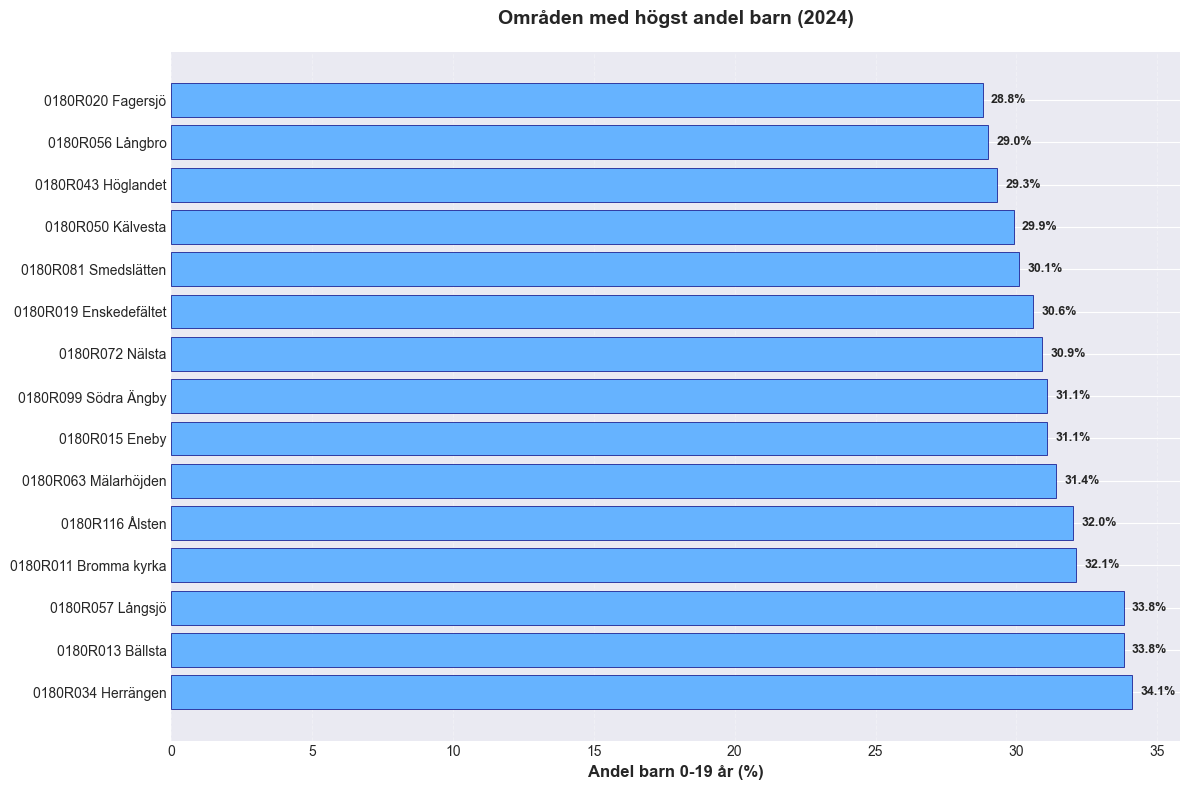

✓ Graf sparad: c:\Users\chris\Documents\github\UrbanPulse\EDA\outputs\omraden_hog_andel_barn.png


In [16]:
# ═══════════════════════════════════════════════════════════════════════════
# Graf 1: Områden med högst andel barn
# ═══════════════════════════════════════════════════════════════════════════
# Visar vilka områden som har störst andel barn (0-19 år)
# Användbart för: Familjer som söker barnvänliga områden

# Ta de 15 områdena med högst andel barn
top_barn = df_alder_kat.nlargest(15, 'Barn_%')[['Statistikområde', 'Barn_%']]

# Skapa horisontellt stapeldiagram (lättare att läsa långa områdesnamn)
fig, ax = plt.subplots(figsize=(12, 8))
bars = ax.barh(
    range(len(top_barn)),      # Y-positioner (0, 1, 2, ...)
    top_barn['Barn_%'],        # Värden (längd på staplarna)
    color='#66b3ff',           # Ljusblå färg
    edgecolor='navy',          # Mörkblå kant
    linewidth=0.5
)

# Y-axel: Områdesnamn
ax.set_yticks(range(len(top_barn)))
ax.set_yticklabels(top_barn['Statistikområde'])

# X-axel: Procentandel
ax.set_xlabel('Andel barn 0-19 år (%)', fontsize=12, fontweight='bold')

# Titel
ax.set_title('Områden med högst andel barn (2024)', fontsize=14, fontweight='bold', pad=20)

# Lägg till rutnät (gör det lättare att läsa exakta värden)
ax.grid(axis='x', alpha=0.3, linestyle='--')

# Lägg till värden på staplarna
for i, (idx, row) in enumerate(top_barn.iterrows()):
    ax.text(row['Barn_%'] + 0.3, i, f"{row['Barn_%']:.1f}%", 
            va='center', fontsize=9, fontweight='bold')

plt.tight_layout()  # Förhindra att labels klipps av
plt.savefig(OUTPUT_DIR / 'omraden_hog_andel_barn.png', dpi=300, bbox_inches='tight')
plt.show()
print(f"✓ Graf sparad: {OUTPUT_DIR / 'omraden_hog_andel_barn.png'}")

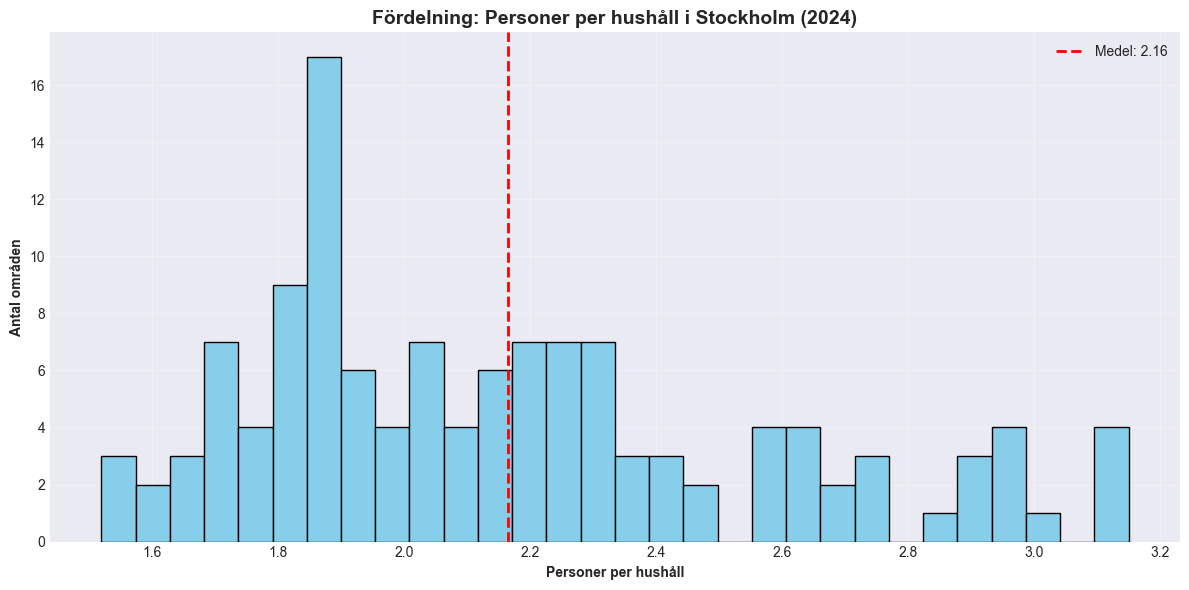

✓ Graf sparad: c:\Users\chris\Documents\github\UrbanPulse\EDA\outputs\personer_per_hushall.png


In [17]:
# ═══════════════════════════════════════════════════════════════════════════
# Graf 2: Fördelning av Personer per Hushåll
# ═══════════════════════════════════════════════════════════════════════════
# Histogram som visar spridningen av personer per hushåll
# Bör vara koncentrerat kring 1.5-2.5 för Stockholm

fig, ax = plt.subplots(figsize=(12, 6))

# Histogram med 30 bins (intervall)
ax.hist(
    df_aggregerad['PersonerPerHushall'].dropna(),  # Ta bort NaN-värden
    bins=30,
    color='skyblue',
    edgecolor='black'  # Svarta kanter mellan staplarna
)

# Lägg till vertikal linje för medelvärdet
mean_val = df_aggregerad['PersonerPerHushall'].mean()
ax.axvline(
    mean_val,
    color='red',
    linestyle='--',
    linewidth=2,
    label=f'Medel: {mean_val:.2f}'
)

ax.set_xlabel('Personer per hushåll', fontweight='bold')
ax.set_ylabel('Antal områden', fontweight='bold')
ax.set_title('Fördelning: Personer per hushåll i Stockholm (2024)', 
             fontsize=14, fontweight='bold')
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'personer_per_hushall.png', dpi=300, bbox_inches='tight')
plt.show()
print(f"✓ Graf sparad: {OUTPUT_DIR / 'personer_per_hushall.png'}")

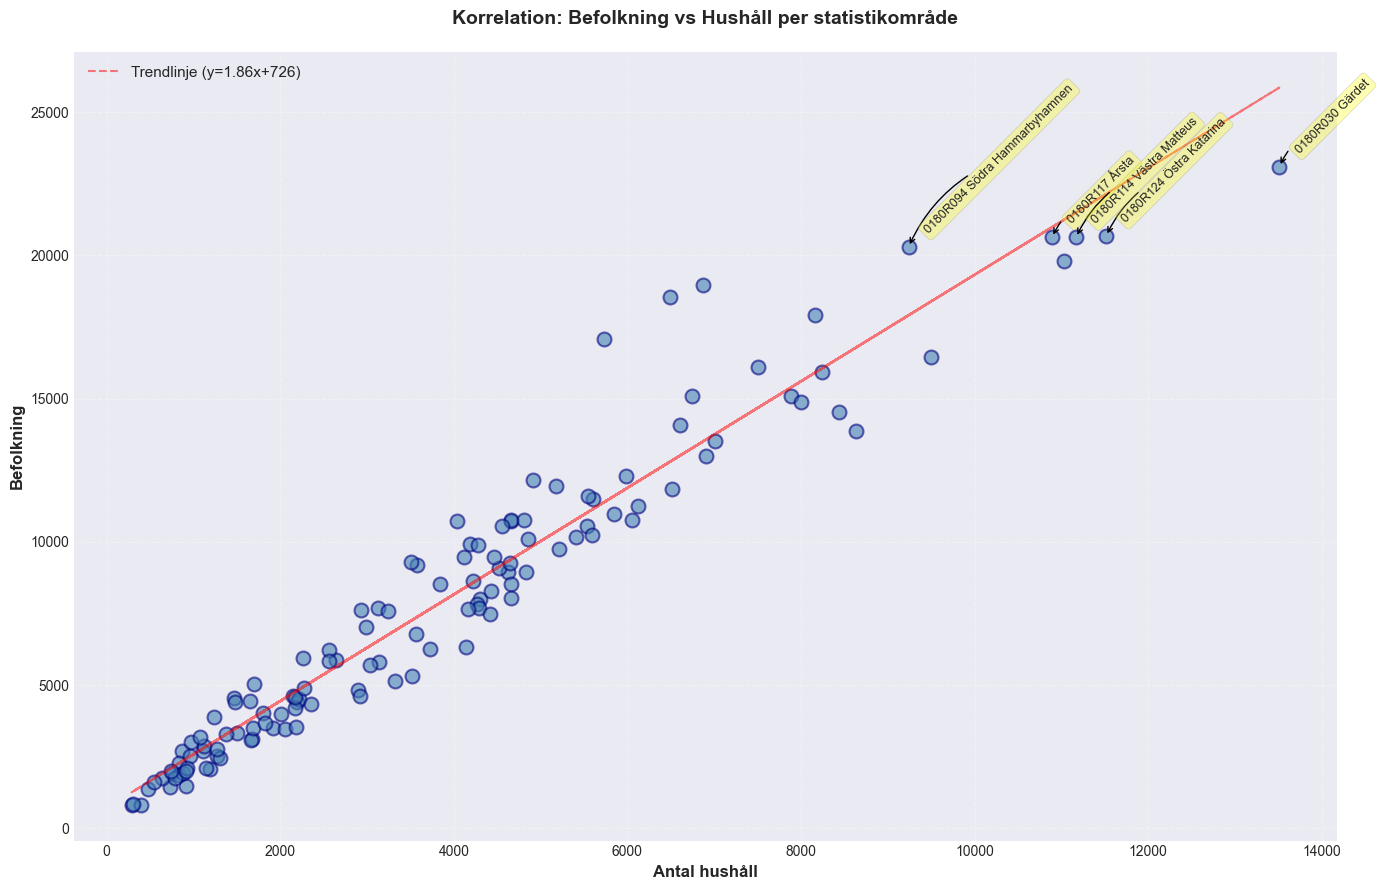

✓ Graf sparad: c:\Users\chris\Documents\github\UrbanPulse\EDA\outputs\korrelation_befolkning_hushall.png


In [18]:
# ═══════════════════════════════════════════════════════════════════════════
# Graf 3: Korrelation Befolkning vs Hushåll
# ═══════════════════════════════════════════════════════════════════════════
# Visar sambandet mellan antal invånare och antal hushåll
# Trendlinjen visar genomsnittligt antal personer per hushåll

fig, ax = plt.subplots(figsize=(14, 9))

# Scatter plot med bättre styling
scatter = ax.scatter(
    df_aggregerad['Hushall'], 
    df_aggregerad['Befolkning'],
    s=100,              # Större punkter
    alpha=0.6,          # Transparent så överlapp syns
    edgecolors='navy',  # Mörkare kant
    linewidths=1.5,
    c='steelblue'       # Mjukare färg
)

# Trendlinje (tunnare och mer diskret)
z = np.polyfit(df_aggregerad['Hushall'], df_aggregerad['Befolkning'], 1)
p = np.poly1d(z)
ax.plot(df_aggregerad['Hushall'], p(df_aggregerad['Hushall']), 
        "r--", alpha=0.5, linewidth=1.5, 
        label=f'Trendlinje (y={z[0]:.2f}x+{z[1]:.0f})')

# Märk ut bara extremvärden (top 5 störst befolkning)
top5 = df_aggregerad.nlargest(5, 'Befolkning')
for idx, row in top5.iterrows():
    ax.annotate(
        row['Statistikområde'],
        xy=(row['Hushall'], row['Befolkning']),
        xytext=(10, 10),
        textcoords='offset points',
        fontsize=9,
        rotation=45,  # Rotera 45 grader
        bbox=dict(boxstyle='round,pad=0.3', facecolor='yellow', alpha=0.3, edgecolor='gray', linewidth=0.5),
        arrowprops=dict(arrowstyle='->', connectionstyle='arc3,rad=0.2', lw=1, color='black')
    )

ax.set_xlabel('Antal hushåll', fontsize=12, fontweight='bold')
ax.set_ylabel('Befolkning', fontsize=12, fontweight='bold')
ax.set_title('Korrelation: Befolkning vs Hushåll per statistikområde', 
             fontsize=14, fontweight='bold', pad=20)
ax.legend(loc='upper left', fontsize=11)
ax.grid(True, alpha=0.3, linestyle='--')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'korrelation_befolkning_hushall.png', dpi=300, bbox_inches='tight')
plt.show()
print(f"✓ Graf sparad: {OUTPUT_DIR / 'korrelation_befolkning_hushall.png'}")

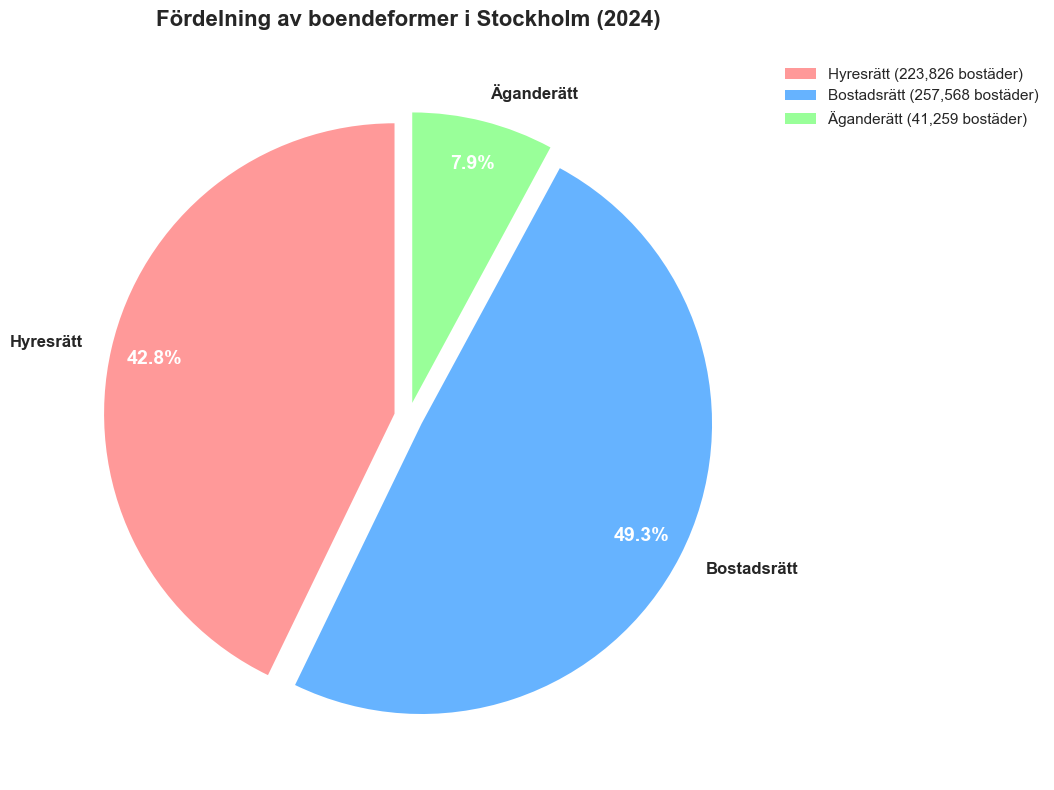

✓ Graf sparad: c:\Users\chris\Documents\github\UrbanPulse\EDA\outputs\boendeform_fordelning.png


In [19]:
# ═══════════════════════════════════════════════════════════════════════════
# Graf 4: Cirkeldiagram - Boendeformer
# ═══════════════════════════════════════════════════════════════════════════
# Visar fördelningen av hyresrätt, bostadsrätt och äganderätt i Stockholm

# Beräkna totala bostäder per upplåtelseform
boende_totalt = df_aggregerad[['hyresrätt', 'bostadsrätt', 'äganderätt']].sum()

# Färger (tydliga och professionella)
colors = ['#ff9999', '#66b3ff', '#99ff99']  # Rosa, Blå, Grön
explode = (0.05, 0.05, 0.05)  # Liten separation mellan alla segment

fig, ax = plt.subplots(figsize=(10, 8))

wedges, texts, autotexts = ax.pie(
    boende_totalt,
    labels=['Hyresrätt', 'Bostadsrätt', 'Äganderätt'],
    autopct='%1.1f%%',
    colors=colors,
    explode=explode,
    startangle=90,
    textprops={'fontsize': 12, 'weight': 'bold'},
    pctdistance=0.85,  # Procenttext längre in
    labeldistance=1.1,  # Labels längre ut
    shadow=False  # INGEN SKUGGA!
)

# Gör procenttexten vit för bättre kontrast
for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontsize(14)
    autotext.set_weight('bold')

ax.set_title('Fördelning av boendeformer i Stockholm (2024)', 
             fontsize=16, fontweight='bold', pad=20)

# Lägg till legend med antal
legend_labels = [
    f"Hyresrätt ({boende_totalt['hyresrätt']:,.0f} bostäder)",
    f"Bostadsrätt ({boende_totalt['bostadsrätt']:,.0f} bostäder)",
    f"Äganderätt ({boende_totalt['äganderätt']:,.0f} bostäder)"
]
ax.legend(legend_labels, loc='upper left', bbox_to_anchor=(1, 1), fontsize=11)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'boendeform_fordelning.png', dpi=300, bbox_inches='tight')
plt.show()
print(f"✓ Graf sparad: {OUTPUT_DIR / 'boendeform_fordelning.png'}")

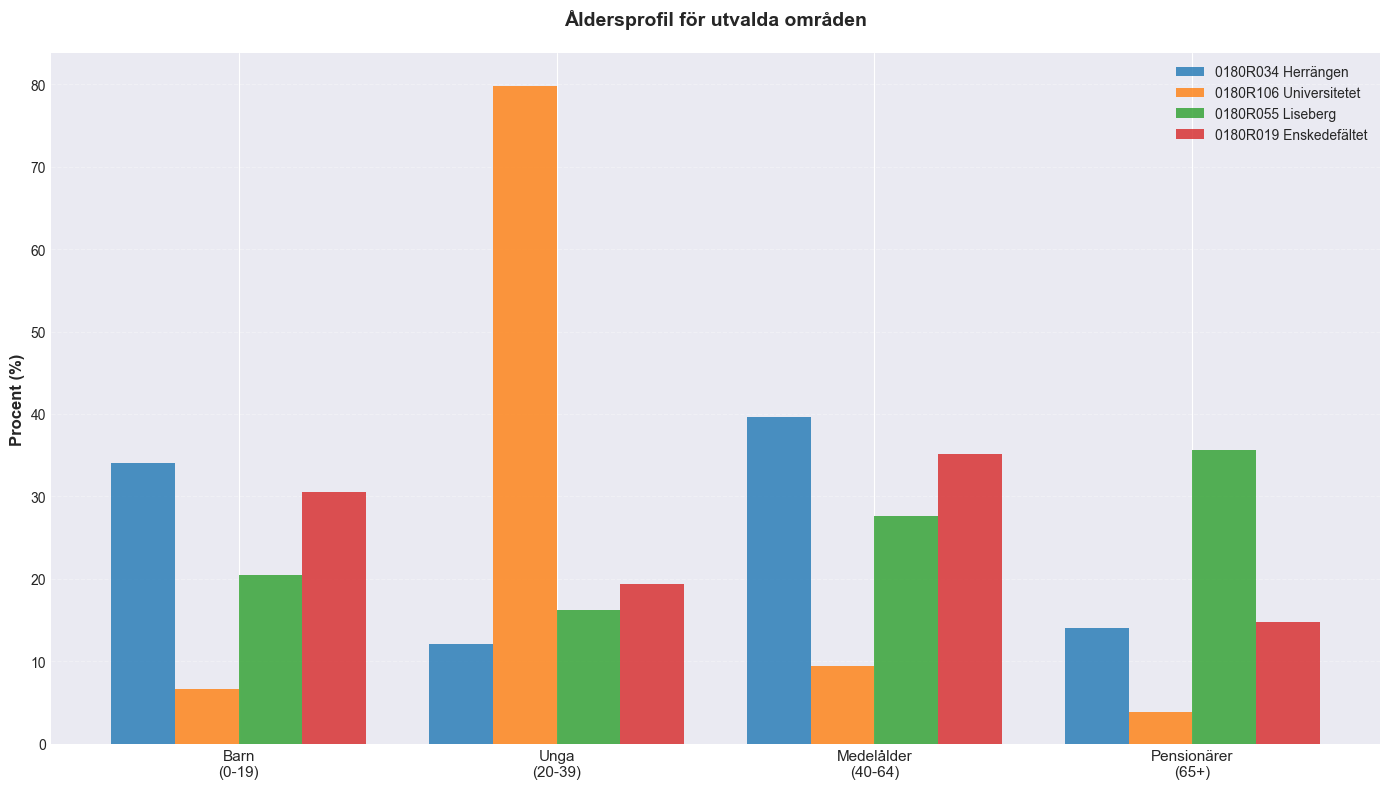

✓ Graf sparad: c:\Users\chris\Documents\github\UrbanPulse\EDA\outputs\aldersprofil_jamforelse.png


In [20]:
# ═══════════════════════════════════════════════════════════════════════════
# Graf 5: Ålderspyramid för utvalda områden
# ═══════════════════════════════════════════════════════════════════════════
# Jämför åldersstrukturen i 4 olika typer av områden

# Välj representativa områden
utvalda = [
    df_alder_kat.nlargest(1, 'Barn_%').iloc[0]['Statistikområde'],      # Mest barn
    df_alder_kat.nlargest(1, 'Unga_%').iloc[0]['Statistikområde'],      # Mest unga
    df_alder_kat.nlargest(1, 'Pensionärer_%').iloc[0]['Statistikområde'], # Mest pensionärer
    'Södermalm' if 'Södermalm' in df_alder_kat['Statistikområde'].values else df_alder_kat.iloc[0]['Statistikområde']
]

# Ta bort dubbletter
utvalda = list(dict.fromkeys(utvalda))[:4]

fig, ax = plt.subplots(figsize=(14, 8))
x = np.arange(4)  # 4 ålderskategorier
width = 0.2

for i, omrade in enumerate(utvalda):
    data = df_alder_kat[df_alder_kat['Statistikområde'] == omrade].iloc[0]
    values = [data['Barn_%'], data['Unga_%'], 
              (data['Medelålder_40_64']/data['TotalBefolkning']*100), 
              data['Pensionärer_%']]
    ax.bar([p + width*i for p in x], values, width, label=omrade, alpha=0.8)

ax.set_ylabel('Procent (%)', fontsize=12, fontweight='bold')
ax.set_title('Åldersprofil för utvalda områden', fontsize=14, fontweight='bold', pad=20)
ax.set_xticks([p + width*1.5 for p in x])
ax.set_xticklabels(['Barn\n(0-19)', 'Unga\n(20-39)', 'Medelålder\n(40-64)', 'Pensionärer\n(65+)'],
                   fontsize=11)
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.3, linestyle='--')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'aldersprofil_jamforelse.png', dpi=300, bbox_inches='tight')
plt.show()
print(f"✓ Graf sparad: {OUTPUT_DIR / 'aldersprofil_jamforelse.png'}")

---
## 4. Skattesatser (hela Sverige)

Kommunal skattesats, regionskatt och total kommunal skattesats för alla Sveriges kommuner.
Används för att visa Stockholms skattenivå i förhållande till rikssnittet.

**Tabell:** TAB2017  
**Nivå:** Kommunnivå (290 kommuner)  
**Hämtas i batchar om 50 kommuner** via GET med URL-parametrar

In [21]:
# ═══════════════════════════════════════════════════════════════════════════
# SKATTESATSER - Hämta data (TAB2017)
# ═══════════════════════════════════════════════════════════════════════════
# Tabellen innehåller 312 regioner (kommuner + län + riket).
# Vi filtrerar till enbart kommuner via 4-siffriga koder (ex. "0180").
# Län har 2-siffriga koder ("01") och riket har "00".
#
# Kolumnnamn efter pivot:
#   'Skattesats till kommun'       – Kommunalskatt (%)
#   'Skattesats till region'       – Regionskatt (%)
#   'Skattesats, total kommunal'   – Summan av ovan (%)

print("Hämtar skattesatser...")

meta_skatt = get_metadata("TAB2017")

# Filtrera kommuner: 4-siffriga koder = kommuner
alla_regioner = list(meta_skatt['dimension']['Region']['category']['label'].keys())
kommuner = [r for r in alla_regioner if len(r) == 4]

ar = list(meta_skatt['dimension']['Tid']['category']['label'].keys())
senaste_ar = ar[-1]

skatt_typer = list(meta_skatt['dimension']['ContentsCode']['category']['label'].keys())

print(f"  {len(kommuner)} kommuner, år {senaste_ar}")

BATCH_SIZE_SKATT = 50
batches = [kommuner[i:i+BATCH_SIZE_SKATT] for i in range(0, len(kommuner), BATCH_SIZE_SKATT)]

print(f"\nHämtar i {len(batches)} batchar...")

all_data = []

for i, batch in enumerate(batches, 1):
    params = [
        f"lang={LANG}",
        "outputFormat=JSON-stat2",
        f"valueCodes[Region]={','.join(batch)}",
        f"valueCodes[ContentsCode]={','.join(skatt_typer)}",
        f"valueCodes[Tid]={senaste_ar}"
    ]
    url = f"{BASE_URL}/tables/TAB2017/data?" + "&".join(params)
    print(f"  Batch {i}/{len(batches)}: {len(batch)} kommuner...", end=' ')
    try:
        r = requests.get(url, timeout=30)
        if r.status_code == 200:
            # Enkel kod→kod-map: ingen namnöversättning behövs för kommundata
            batch_map = {k: k for k in batch}
            batch_df = jsonstat2_to_df(r.json(), batch_map)
            all_data.append(batch_df)
            print(f"✓ ({len(batch_df)} rader)")
        else:
            print(f"✗ HTTP {r.status_code}")
    except Exception as e:
        print(f"✗ {str(e)[:50]}")

if not all_data:
    print("\n❌ Alla batchar misslyckades!")
else:
    df_skatt_raw = pd.concat(all_data, ignore_index=True)
    print(f"\n✓ Total: {len(df_skatt_raw)} rader från {len(all_data)} batchar")
    
    # Pivotera från long till wide: en rad per kommun, en kolumn per skattetyp
    df_skatt = df_skatt_raw.pivot_table(
        index=['Region', 'Tid'],
        columns='ContentsCode',
        values='value',
        aggfunc='first'
    ).reset_index()
    df_skatt.columns.name = None
    
    skatt_file = DATA_DIR / f'sverige_skattesatser_{senaste_ar}.csv'
    df_skatt.to_csv(skatt_file, index=False, encoding='utf-8-sig')
    print(f"\n✓ Sparat: {skatt_file}")
    print(f"  {len(df_skatt)} kommuner")
    df_skatt.head(10)

Hämtar skattesatser...
  290 kommuner, år 2026

Hämtar i 6 batchar...
  Batch 1/6: 50 kommuner... ✓ (150 rader)
  Batch 2/6: 50 kommuner... ✓ (150 rader)
  Batch 3/6: 50 kommuner... ✓ (150 rader)
  Batch 4/6: 50 kommuner... ✓ (150 rader)
  Batch 5/6: 50 kommuner... ✓ (150 rader)
  Batch 6/6: 40 kommuner... ✓ (120 rader)

✓ Total: 870 rader från 6 batchar

✓ Sparat: c:\Users\chris\Documents\github\UrbanPulse\data_files\sverige_skattesatser_2026.csv
  290 kommuner


In [22]:
# ═══════════════════════════════════════════════════════════════════════════
# SKATTESATSER - DuckDB analys
# ═══════════════════════════════════════════════════════════════════════════
# OBS: Kolumnnamnet 'Skattesats, total kommunal' innehåller komma och
# mellanslag. I DuckDB måste sådana kolumnnamn omges av dubbla citattecken.

# Stockholm: skattesatser, ranking och jämförelse mot rikssnitt
query_sthlm = """
SELECT 
    Region,
    "Skattesats till kommun" as Kommunalskatt,
    "Skattesats till region" as Regionskatt,
    "Skattesats, total kommunal" as Total_skattesats,
    RANK() OVER (ORDER BY "Skattesats, total kommunal") as Ranking,
    ROUND((SELECT AVG("Skattesats, total kommunal") FROM df_skatt), 2) as Rikssnitt
FROM df_skatt
WHERE Region = '0180'
"""

df_sthlm = duckdb.query(query_sthlm).to_df()
print("="*60)
print("STOCKHOLMS KOMMUNS SKATTESATSER")
print("="*60)
print(df_sthlm)
print("="*60)

hogst = df_skatt['Skattesats, total kommunal'].max()
lagst = df_skatt['Skattesats, total kommunal'].min()
print(f"\nHögsta skattesats i Sverige: {hogst:.2f}%")
print(f"Lägsta skattesats i Sverige: {lagst:.2f}%")
print(f"Stockholm: {df_sthlm['Total_skattesats'].iloc[0]:.2f}% (ranking {df_sthlm['Ranking'].iloc[0]} av {len(df_skatt)})")

STOCKHOLMS KOMMUNS SKATTESATSER
  Region  Kommunalskatt  Regionskatt  Total_skattesats  Ranking  Rikssnitt
0   0180          18.22        12.33             30.55        1       33.3

Högsta skattesats i Sverige: 35.65%
Lägsta skattesats i Sverige: 28.93%
Stockholm: 30.55% (ranking 1 av 290)


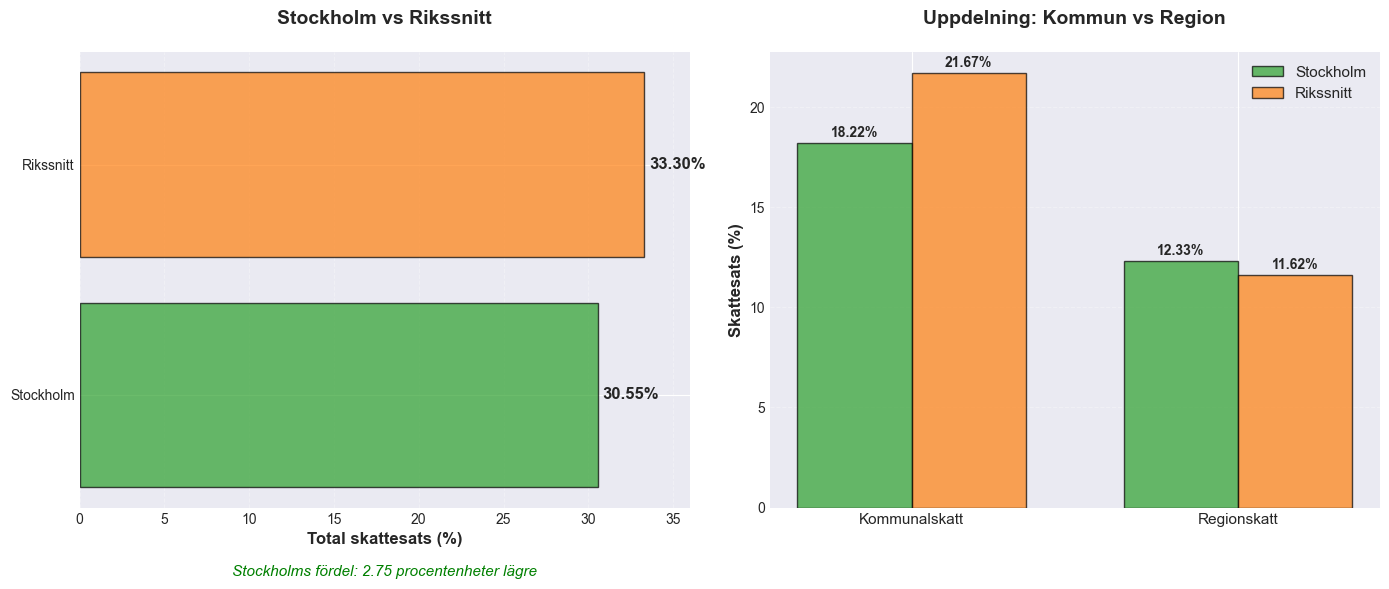

✓ Graf sparad: c:\Users\chris\Documents\github\UrbanPulse\EDA\outputs\skattesatser_stockholm_vs_riket.png


In [23]:
# ═══════════════════════════════════════════════════════════════════════════
# SKATTESATSER - Visualisering (Stockholm vs Rikssnitt)
# ═══════════════════════════════════════════════════════════════════════════

# Beräkna rikssnitt
rikssnitt = df_skatt['Skattesats, total kommunal'].mean()

# Stockholm
stockholm_skatt = df_skatt[df_skatt['Region'] == '0180']['Skattesats, total kommunal'].iloc[0]
stockholm_kommun = df_skatt[df_skatt['Region'] == '0180']['Skattesats till kommun'].iloc[0]
stockholm_region = df_skatt[df_skatt['Region'] == '0180']['Skattesats till region'].iloc[0]

# Skapa figur
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# GRAF 1: Stockholm vs Rikssnitt (Total)
ax1.barh(['Stockholm', 'Rikssnitt'], 
         [stockholm_skatt, rikssnitt],
         color=['#2ca02c', '#ff7f0e'],
         alpha=0.7,
         edgecolor='black')

# Värden på staplarna
ax1.text(stockholm_skatt + 0.3, 0, f'{stockholm_skatt:.2f}%', 
         va='center', fontsize=12, fontweight='bold')
ax1.text(rikssnitt + 0.3, 1, f'{rikssnitt:.2f}%', 
         va='center', fontsize=12, fontweight='bold')

ax1.set_xlabel('Total skattesats (%)', fontsize=12, fontweight='bold')
ax1.set_title('Stockholm vs Rikssnitt', fontsize=14, fontweight='bold', pad=20)
ax1.grid(axis='x', alpha=0.3, linestyle='--')
ax1.set_xlim(0, 36)

# Skillnad-text
skillnad = stockholm_skatt - rikssnitt
ax1.text(0.5, -0.15, f'Stockholms fördel: {abs(skillnad):.2f} procentenheter lägre', 
         fontsize=11, style='italic', color='green',
         transform=ax1.transAxes, ha='center')

# GRAF 2: Uppdelning (Kommun vs Region)
categories = ['Kommunalskatt', 'Regionskatt']
stockholm_parts = [stockholm_kommun, stockholm_region]

x = range(len(categories))
width = 0.35

# Stockholm
bars1 = ax2.bar([i - width/2 for i in x], stockholm_parts, width,
                label='Stockholm', color='#2ca02c', alpha=0.7, edgecolor='black')

# Rikssnitt
rikssnitt_kommun = df_skatt['Skattesats till kommun'].mean()
rikssnitt_region = df_skatt['Skattesats till region'].mean()
rikssnitt_parts = [rikssnitt_kommun, rikssnitt_region]

bars2 = ax2.bar([i + width/2 for i in x], rikssnitt_parts, width,
                label='Rikssnitt', color='#ff7f0e', alpha=0.7, edgecolor='black')

# Värden på staplarna
for i, (s, r) in enumerate(zip(stockholm_parts, rikssnitt_parts)):
    ax2.text(i - width/2, s + 0.3, f'{s:.2f}%', 
             ha='center', fontsize=10, fontweight='bold')
    ax2.text(i + width/2, r + 0.3, f'{r:.2f}%', 
             ha='center', fontsize=10, fontweight='bold')

ax2.set_ylabel('Skattesats (%)', fontsize=12, fontweight='bold')
ax2.set_title('Uppdelning: Kommun vs Region', fontsize=14, fontweight='bold', pad=20)
ax2.set_xticks(x)
ax2.set_xticklabels(categories, fontsize=11)
ax2.legend(fontsize=11)
ax2.grid(axis='y', alpha=0.3, linestyle='--')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'skattesatser_stockholm_vs_riket.png', dpi=300, bbox_inches='tight')
plt.show()
print(f"✓ Graf sparad: {OUTPUT_DIR / 'skattesatser_stockholm_vs_riket.png'}")

---
## 5. Socioekonomiska indikatorer (RegSO)

Tre indikatorer som ger en socioekonomisk bild av varje RegSO-område:

- **Socioekonomiskt index** – Sammansatt mått (lägre = sämre förutsättningar)
- **Andel med låg ekonomisk standard** – Procent av befolkningen
- **Andel med ekonomiskt bistånd och/eller långtidsarbetslösa** – Procent

Analysen fokuserar på jämförelsen mellan **Bromma** och **Hägersten-Älvsjö**
– de två stadsdelsnämnder som dashboarden täcker.

**Tabell:** TAB6586  
**Nivå:** RegSO (hela Sverige, vi filtrerar till Stockholm)  
**Hämtas i batchar om 50 RegSO-koder** via GET med URL-parametrar

In [24]:
# ═══════════════════════════════════════════════════════════════════════════
# SOCIOEKONOMISKA INDIKATORER - Hämta data (TAB6586)
# ═══════════════════════════════════════════════════════════════════════════
# Regionkoderna i TAB6586 ser ut som '0180R001' – kortare format än
# folkmängdstabellerna ('0180R001_RegSO2025'). Vi filtrerar på prefix '0180R'.

print("Hämtar socioekonomiska indikatorer...")

meta_socio = get_metadata("TAB6586")

# Filtrera Stockholm RegSO: koder som börjar med '0180R'
alla_regioner_socio = meta_socio['dimension']['Region']['category']
sthlm_koder = [
    kod for kod, label in alla_regioner_socio['label'].items()
    if kod.startswith('0180R')
]

ar_socio = list(meta_socio['dimension']['Tid']['category']['label'].keys())
senaste_ar_socio = ar_socio[-1]

indikatorer = list(meta_socio['dimension']['ContentsCode']['category']['label'].keys())

print(f"  {len(sthlm_koder)} Stockholm RegSO-områden")
print(f"  År: {senaste_ar_socio}")
print(f"  Indikatorer: {indikatorer}")

batches_socio = [sthlm_koder[i:i+50] for i in range(0, len(sthlm_koder), 50)]
print(f"\nHämtar i {len(batches_socio)} batchar...")

all_socio = []

for i, batch in enumerate(batches_socio, 1):
    params = [
        f"lang={LANG}",
        "outputFormat=JSON-stat2",
        f"valueCodes[Region]={','.join(batch)}",
        f"valueCodes[ContentsCode]={','.join(indikatorer)}",
        f"valueCodes[Tid]={senaste_ar_socio}"
    ]
    url = f"{BASE_URL}/tables/TAB6586/data?" + "&".join(params)
    print(f"  Batch {i}/{len(batches_socio)}: {len(batch)} områden...", end=' ')
    try:
        r = requests.get(url, timeout=30)
        if r.status_code == 200:
            batch_map = {k: k for k in batch}
            batch_df = jsonstat2_to_df(r.json(), batch_map)
            all_socio.append(batch_df)
            print(f"✓ ({len(batch_df)} rader)")
        else:
            print(f"✗ HTTP {r.status_code}")
    except Exception as e:
        print(f"✗ {str(e)[:50]}")

df_socio_raw = pd.concat(all_socio, ignore_index=True)

# Pivotera till wide format: en rad per område, en kolumn per indikator
df_socio = df_socio_raw.pivot_table(
    index=['Region', 'Tid'],
    columns='ContentsCode',
    values='value',
    aggfunc='first'
).reset_index()
df_socio.columns.name = None

# Lägg till läsbart områdesnamn: "Stockholm (Abrahamsberg)" → "Abrahamsberg"
region_labels = alla_regioner_socio['label']
df_socio['Omrade'] = df_socio['Region'].map(
    lambda k: region_labels.get(k, k)
    .replace('Stockholm (', '')
    .replace(')', '')
)

# Lägg till stadsdelsomrade via mappningsfunktionen
df_socio = lagg_till_stadsdel(df_socio, 'Omrade')
bromma_s = (df_socio['stadsdelsomrade'] == 'Bromma').sum()
hag_s    = (df_socio['stadsdelsomrade'] == 'Hägersten-Älvsjö').sum()
nan_s    = df_socio['stadsdelsomrade'].isna().sum()
print(f"  Stadsdelmappning: Bromma {bromma_s}, Hägersten-Älvsjö {hag_s}, NaN {nan_s}")

socio_file = DATA_DIR / f'stockholm_socioekonomiskt_{senaste_ar_socio}.csv'
df_socio.to_csv(socio_file, index=False, encoding='utf-8-sig')

print(f"\n✓ Sparat: {socio_file}")
print(f"  {len(df_socio)} områden")
print(f"  Kolumner: {list(df_socio.columns)}")
df_socio.head()

Hämtar socioekonomiska indikatorer...
  254 Stockholm RegSO-områden
  År: 2024
  Indikatorer: ['000008IT', '000008IU', '000008IV', '000008IW', '000008IX']

Hämtar i 6 batchar...
  Batch 1/6: 50 områden... ✓ (250 rader)
  Batch 2/6: 50 områden... ✓ (250 rader)
  Batch 3/6: 50 områden... ✓ (250 rader)
  Batch 4/6: 50 områden... ✓ (250 rader)
  Batch 5/6: 50 områden... ✗ HTTPSConnectionPool(host='statistikdatabasen.scb.s
  Batch 6/6: 4 områden... ✓ (20 rader)
  Stadsdelmappning: Bromma 14, Hägersten-Älvsjö 11, NaN 77

✓ Sparat: c:\Users\chris\Documents\github\UrbanPulse\data_files\stockholm_socioekonomiskt_2024.csv
  102 områden
  Kolumner: ['Region', 'Tid', 'Andelen med ekonomiskt bistånd och/eller långtidsarbetslösa', 'Andelen med förgymnasial utbildning', 'Andelen personer med låg ekonomisk standard (oavsett ålder)', 'Områdestyp', 'Socioekonomiskt index', 'Omrade', 'stadsdelsomrade']


,Region,Tid,Andelen med ekonomiskt bistånd och/eller långtidsarbetslösa,Andelen med förgymnasial utbildning,Andelen personer med låg ekonomisk standard (oavsett ålder),Områdestyp,Socioekonomiskt index,Omrade,stadsdelsomrade
0,0180R001_RegSO2025,2024,2.7,5.3,7.7,4.0,5.2,0180R001 Abrahamsberg,Bromma
1,0180R002_RegSO2025,2024,5.5,15.5,21.7,2.0,14.2,0180R002 Akalla,NaN
2,0180R003_RegSO2025,2024,1.0,1.7,6.4,5.0,3.0,0180R003 Alvik,Bromma
3,0180R004_RegSO2025,2024,3.0,4.9,9.0,4.0,5.6,0180R004 Aspudden,Hägersten-Älvsjö
4,0180R005_RegSO2025,2024,3.8,7.7,14.0,4.0,8.5,0180R005 Bagarmossen,NaN


In [25]:
# ═══════════════════════════════════════════════════════════════════════════
# SOCIOEKONOMISKA INDIKATORER - DuckDB analys
# ═══════════════════════════════════════════════════════════════════════════
# Kolumnnamnen från SCB är långa och innehåller specialtecken.
# Vi hittar dem dynamiskt med str-sökning istället för att hårdkoda –
# gör koden robust mot framtida uppdateringar av SCB:s etiketter.

socio_cols = [c for c in df_socio.columns if c not in ['Region', 'Tid', 'Omrade']]
print(f"Tillgängliga indikatorer: {socio_cols}")

# Hitta rätt kolumnnamn dynamiskt
col_index   = [c for c in socio_cols if 'index' in c.lower() or 'Index' in c][0]
col_lag_ek  = [c for c in socio_cols if 'låg ekonomisk' in c.lower() or 'lag ekonomisk' in c.lower()][0]
col_bistand = [c for c in socio_cols if 'bistånd' in c.lower() or 'bistand' in c.lower()][0]

print(f"\nAnvänder kolumner:")
print(f"  Index:          {col_index}")
print(f"  Låg ek.std:     {col_lag_ek}")
print(f"  Bistånd/arblös: {col_bistand}")

# ───────────────────────────────────────────────────────────────────────────
# Klassificera RegSO-områden till stadsdelsnämnd via namnmatchning
# ───────────────────────────────────────────────────────────────────────────
# TAB6586 har ingen stadsdelsnämnd-dimension, så vi matchar
# områdesnamn mot kända listor för varje stadsdel.
bromma_omraden = [
    'Abrahamsberg', 'Alvik', 'Beckomberga', 'Blackeberg', 'Bromma kyrka',
    'Bromsten', 'Eneby', 'Flysta', 'Grimsta', 'Islandstorget', 'Nockebyhov',
    'Nockeby', 'Olovslund', 'Råcksta', 'Riksby', 'Södra Ängby', 'Traneberg',
    'Ulvsunda', 'Vällingby', 'Åkeslund', 'Åkeshov', 'Äppelviken'
]
hagersten_omraden = [
    'Hägersten', 'Hägerstensåsen', 'Långbro', 'Västertorp', 'Midsommarkransen',
    'Fruängen', 'Älvsjö', 'Örby', 'Örby slott', 'Liseberg', 'Solberga'
]

df_socio['Stadsdel'] = df_socio['Omrade'].apply(
    lambda x: 'Bromma' if any(o.lower() in x.lower() for o in bromma_omraden)
    else ('Hägersten-Älvsjö' if any(o.lower() in x.lower() for o in hagersten_omraden)
    else 'Övrigt')
)

# Aggregera per stadsdel för en snabb jämförelse
query_stadsdel = f"""
SELECT 
    Stadsdel,
    ROUND(AVG("{col_index}"), 2) as Snitt_index,
    ROUND(AVG("{col_lag_ek}"), 2) as Snitt_lag_ekonomisk_std,
    ROUND(AVG("{col_bistand}"), 2) as Snitt_bistand_arbetslosa,
    COUNT(*) as Antal_omraden
FROM df_socio
WHERE Stadsdel != 'Övrigt'
GROUP BY Stadsdel
ORDER BY Stadsdel
"""

df_stadsdel = duckdb.query(query_stadsdel).to_df()
print("\nBromma vs Hägersten-Älvsjö:")
print(df_stadsdel)

Tillgängliga indikatorer: ['Andelen med ekonomiskt bistånd och/eller långtidsarbetslösa', 'Andelen med förgymnasial utbildning', 'Andelen personer med låg ekonomisk standard (oavsett ålder)', 'Områdestyp', 'Socioekonomiskt index', 'stadsdelsomrade']

Använder kolumner:
  Index:          Socioekonomiskt index
  Låg ek.std:     Andelen personer med låg ekonomisk standard (oavsett ålder)
  Bistånd/arblös: Andelen med ekonomiskt bistånd och/eller långtidsarbetslösa

Bromma vs Hägersten-Älvsjö:
           Stadsdel  Snitt_index  Snitt_lag_ekonomisk_std  \
0            Bromma         5.64                     8.28   
1  Hägersten-Älvsjö         4.97                     7.29   

   Snitt_bistand_arbetslosa  Antal_omraden  
0                      2.79             14  
1                      2.37              7  


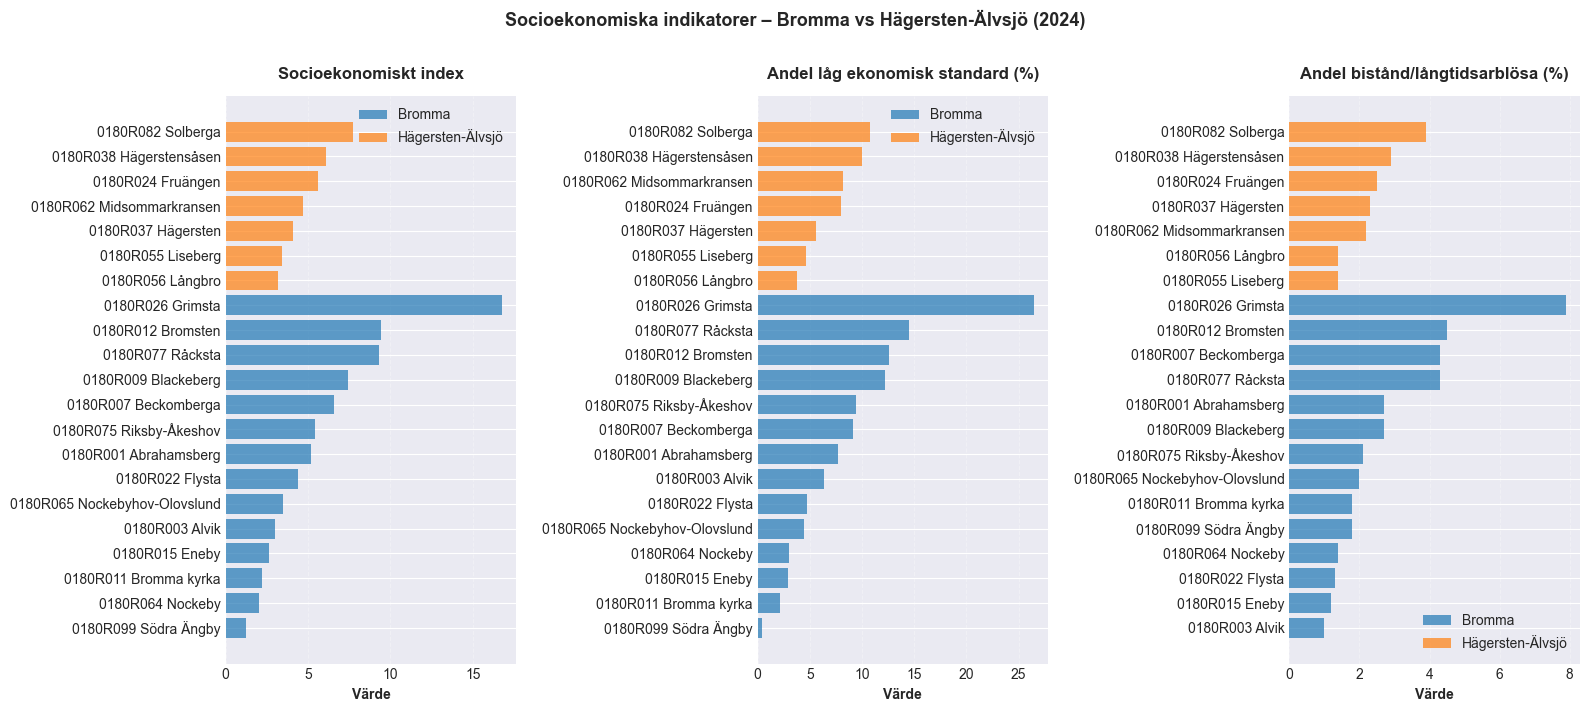

✓ Graf sparad: c:\Users\chris\Documents\github\UrbanPulse\EDA\outputs\socioekonomiskt_bromma_vs_hagersten.png


In [26]:
# ═══════════════════════════════════════════════════════════════════════════
# SOCIOEKONOMISKA INDIKATORER - Visualisering
# ═══════════════════════════════════════════════════════════════════════════

df_plot = df_socio[df_socio['Stadsdel'] != 'Övrigt'].copy()

fig, axes = plt.subplots(1, 3, figsize=(16, 7))

colors = {'Bromma': '#1f77b4', 'Hägersten-Älvsjö': '#ff7f0e'}
indikatorer_plot = [
    (col_index,   'Socioekonomiskt index',              axes[0]),
    (col_lag_ek,  'Andel låg ekonomisk standard (%)',   axes[1]),
    (col_bistand, 'Andel bistånd/långtidsarblösa (%)',  axes[2]),
]

for col, titel, ax in indikatorer_plot:
    for stadsdel, color in colors.items():
        data = df_plot[df_plot['Stadsdel'] == stadsdel].sort_values(col)
        ax.barh(
            data['Omrade'], data[col],
            color=color, alpha=0.7, label=stadsdel
        )
    ax.set_title(titel, fontweight='bold', pad=12)
    ax.set_xlabel('Värde', fontweight='bold')
    ax.grid(axis='x', alpha=0.3, linestyle='--')
    ax.legend()

plt.suptitle(
    f'Socioekonomiska indikatorer – Bromma vs Hägersten-Älvsjö ({senaste_ar_socio})',
    fontsize=13, fontweight='bold', y=1.01
)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'socioekonomiskt_bromma_vs_hagersten.png', dpi=300, bbox_inches='tight')
plt.show()
print(f"✓ Graf sparad: {OUTPUT_DIR / 'socioekonomiskt_bromma_vs_hagersten.png'}")

---
## 6. Snittinkomst per kommun (hela Sverige)

Medelinkomst och medianinkomst för alla Sveriges kommuner.
Inkluderas för **framtida skalning** – om dashboarden utökas bortom Stockholm
finns inkomstdata redan insamlad och exporterad.

**Tabell:** TAB3554  
**Nivå:** Kommunnivå (290 kommuner)  
**Filter:** Totalt kön (`1+2`), 20+ år (`tot20+`), alla inkomstklasser (`TOT`)  
**OBS:** `+` i SCB-koder måste URL-encodas till `%2B`, annars ger API:et 400 Bad Request

In [27]:
# ═══════════════════════════════════════════════════════════════════════════
# SNITTINKOMST KOMMUNER - Hämta data (TAB3554)
# ═══════════════════════════════════════════════════════════════════════════
# TAB3554 har dimensionerna: Region, Kön, Ålder, Inkomstklass, ContentsCode, Tid.
# Vi filtrerar till totalt för kön, ålder och inkomstklass för att
# få ett enda medelinkomstvärde per kommun.
#
# VIKTIGT – URL-encoding av specialtecken:
#   Kön "totalt" har koden "1+2"     → encodas till "1%2B2"
#   Ålder "totalt 20+" har "tot20+"  → encodas till "tot20%2B"
#   Utan korrekt encoding: 400 Bad Request från SCB.

print("Hämtar snittinkomst per kommun...")

meta_ink = get_metadata("TAB3554")

# Filtrera kommuner (4-siffriga koder)
alla_reg_ink = meta_ink['dimension']['Region']['category']
kommuner_ink = [k for k in alla_reg_ink['label'].keys() if len(k) == 4]

ar_ink_tillgangliga = list(meta_ink['dimension']['Tid']['category']['label'].keys())
ar_ink = [a for a in AR if a in ar_ink_tillgangliga]
ar_ink_label = f"{ar_ink[0]}_{ar_ink[-1]}"
senaste_ar_ink = ar_ink[-1]

print(f"  {len(kommuner_ink)} kommuner, år {senaste_ar_ink}")

# URL-encodade parametervärden (+ → %2B)
KON_TOT   = '1%2B2'      # Totalt (män + kvinnor)
ALDER_TOT = 'tot20%2B'   # Totalt 20+ år
KLASS_TOT = 'TOT'        # Alla inkomstklasser
CONTENTS  = 'HE0110J7,HE0110J8'  # Medelinkomst (tkr) + Medianinkomst (tkr)

batches_ink = [kommuner_ink[i:i+50] for i in range(0, len(kommuner_ink), 50)]
print(f"\nHämtar i {len(batches_ink)} batchar...")

all_ink = []

for i, batch in enumerate(batches_ink, 1):
    params = [
        f"lang={LANG}",
        "outputFormat=JSON-stat2",
        f"valueCodes[Region]={','.join(batch)}",
        f"valueCodes[Kon]={KON_TOT}",
        f"valueCodes[Alder]={ALDER_TOT}",
        f"valueCodes[Inkomstklass]={KLASS_TOT}",
        f"valueCodes[ContentsCode]={CONTENTS}",
        f"valueCodes[Tid]={senaste_ar_ink}"
    ]
    url = f"{BASE_URL}/tables/TAB3554/data?" + "&".join(params)
    print(f"  Batch {i}/{len(batches_ink)}: {len(batch)} kommuner...", end=' ')
    try:
        r = requests.get(url, timeout=30)
        if r.status_code == 200:
            batch_map = {k: k for k in batch}
            batch_df = jsonstat2_to_df(r.json(), batch_map)
            all_ink.append(batch_df)
            print(f"✓ ({len(batch_df)} rader)")
        else:
            print(f"✗ HTTP {r.status_code}: {r.text[:100]}")
    except Exception as e:
        print(f"✗ {str(e)[:50]}")

# Kombinera och pivotera till wide format
df_ink_raw = pd.concat(all_ink, ignore_index=True)

df_ink = df_ink_raw.pivot_table(
    index=['Region', 'Tid'],
    columns='ContentsCode',
    values='value',
    aggfunc='first'
).reset_index()
df_ink.columns.name = None

# Lägg till läsbart kommunnamn
df_ink['Kommun'] = df_ink['Region'].map(alla_reg_ink['label'])

ink_file = DATA_DIR / f'sverige_snittinkomst_{senaste_ar_ink}.csv'
df_ink.to_csv(ink_file, index=False, encoding='utf-8-sig')

print(f"\n✓ Sparat: {ink_file}")
print(f"  {len(df_ink)} kommuner")
print(f"  Kolumner: {list(df_ink.columns)}")
df_ink.head(10)

Hämtar snittinkomst per kommun...
  290 kommuner, år 2024

Hämtar i 6 batchar...
  Batch 1/6: 50 kommuner... ✓ (100 rader)
  Batch 2/6: 50 kommuner... ✓ (100 rader)
  Batch 3/6: 50 kommuner... ✓ (100 rader)
  Batch 4/6: 50 kommuner... ✓ (100 rader)
  Batch 5/6: 50 kommuner... ✓ (100 rader)
  Batch 6/6: 40 kommuner... ✓ (80 rader)

✓ Sparat: c:\Users\chris\Documents\github\UrbanPulse\data_files\sverige_snittinkomst_2024.csv
  290 kommuner
  Kolumner: ['Region', 'Tid', 'Medelinkomst, tkr', 'Medianinkomst, tkr', 'Kommun']


,Region,Tid,"Medelinkomst, tkr","Medianinkomst, tkr",Kommun
0,0114,2024,402.2,369.9,Upplands Väsby
1,0115,2024,465.0,420.7,Vallentuna
2,0117,2024,473.2,412.2,Österåker
3,0120,2024,473.3,418.3,Värmdö
4,0123,2024,407.8,375.1,Järfälla
5,0125,2024,544.9,440.9,Ekerö
6,0126,2024,426.8,386.4,Huddinge
7,0127,2024,352.7,331.8,Botkyrka
8,0128,2024,437.7,404.0,Salem
9,0136,2024,389.7,369.4,Haninge


In [28]:
# ═══════════════════════════════════════════════════════════════════════════
# SNITTINKOMST - DuckDB analys
# ═══════════════════════════════════════════════════════════════════════════
# Kolumnnamnen från SCB är 'Medelinkomst, tkr' och 'Medianinkomst, tkr'.
# Vi hittar dem dynamiskt för att vara robusta mot SCB-uppdateringar.

ink_cols = [c for c in df_ink.columns if c not in ['Region', 'Tid', 'Kommun']]
print(f"Tillgängliga kolumner: {ink_cols}")

col_medel  = [c for c in ink_cols if 'Medel' in c or 'medel' in c][0]
col_median = [c for c in ink_cols if 'Median' in c or 'median' in c][0]

print(f"  Medelinkomst:  {col_medel}")
print(f"  Medianinkomst: {col_median}")

# Stockholm: inkomst, ranking och jämförelse mot rikssnitt
query_ink = f"""
SELECT 
    Kommun,
    "{col_medel}" as Medelinkomst_tkr,
    "{col_median}" as Medianinkomst_tkr,
    RANK() OVER (ORDER BY "{col_medel}" DESC) as Ranking,
    ROUND((SELECT AVG("{col_medel}") FROM df_ink), 1) as Rikssnitt_tkr
FROM df_ink
WHERE Kommun LIKE '%Stockholm%'
"""

df_ink_sthlm = duckdb.query(query_ink).to_df()
print("\n" + "="*60)
print("STOCKHOLMS KOMMUNS INKOMSTER")
print("="*60)
print(df_ink_sthlm)
print("="*60)

Tillgängliga kolumner: ['Medelinkomst, tkr', 'Medianinkomst, tkr']
  Medelinkomst:  Medelinkomst, tkr
  Medianinkomst: Medianinkomst, tkr

STOCKHOLMS KOMMUNS INKOMSTER
      Kommun  Medelinkomst_tkr  Medianinkomst_tkr  Ranking  Rikssnitt_tkr
0  Stockholm             485.9              413.6        1          374.5


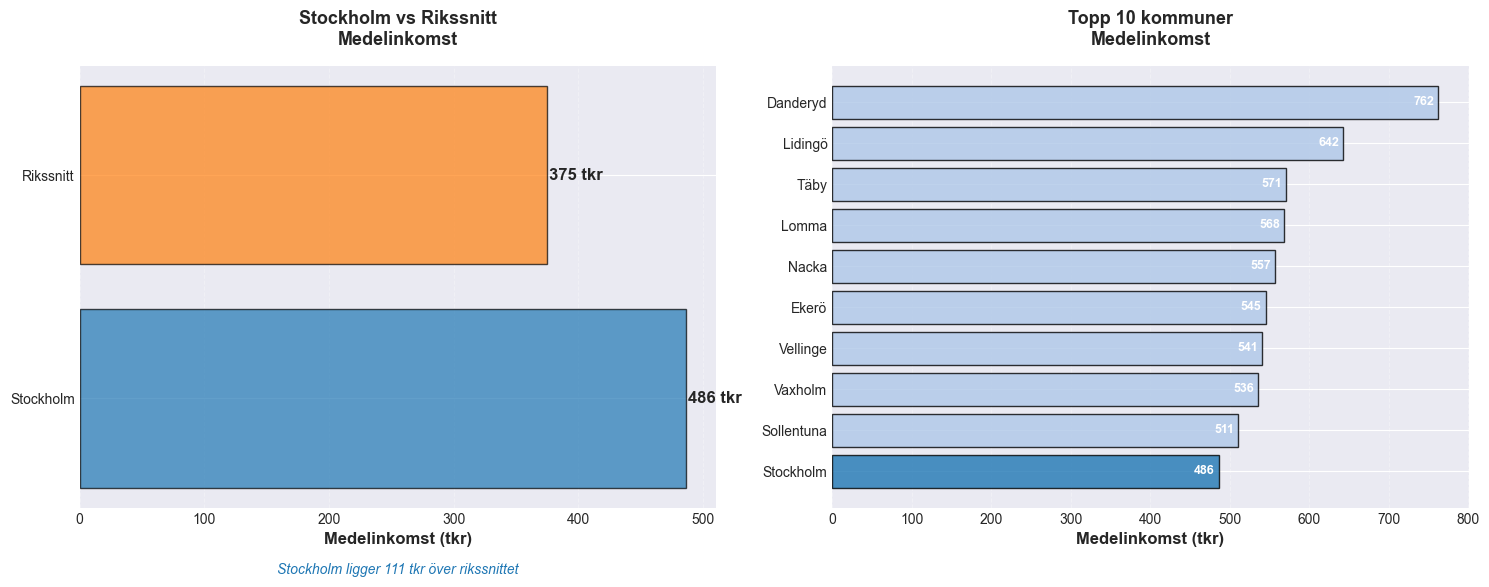

✓ Graf sparad: c:\Users\chris\Documents\github\UrbanPulse\EDA\outputs\snittinkomst_stockholm_vs_riket.png


In [29]:
# ═══════════════════════════════════════════════════════════════════════════
# SNITTINKOMST - Visualisering (Stockholm vs Rikssnitt + Topp 10)
# ═══════════════════════════════════════════════════════════════════════════

rikssnitt_ink = df_ink[col_medel].mean()
stockholm_ink = df_ink[df_ink['Kommun'].str.contains('Stockholm', na=False)][col_medel].iloc[0]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# GRAF 1: Stockholm vs Rikssnitt
ax1.barh(['Stockholm', 'Rikssnitt'],
         [stockholm_ink, rikssnitt_ink],
         color=['#1f77b4', '#ff7f0e'], alpha=0.7, edgecolor='black')

ax1.text(stockholm_ink + 2, 0, f'{stockholm_ink:.0f} tkr',
         va='center', fontsize=12, fontweight='bold')
ax1.text(rikssnitt_ink + 2, 1, f'{rikssnitt_ink:.0f} tkr',
         va='center', fontsize=12, fontweight='bold')

ax1.set_xlabel('Medelinkomst (tkr)', fontsize=12, fontweight='bold')
ax1.set_title('Stockholm vs Rikssnitt\nMedelinkomst', fontsize=13, fontweight='bold', pad=15)
ax1.grid(axis='x', alpha=0.3, linestyle='--')

skillnad_ink = stockholm_ink - rikssnitt_ink
ax1.text(0.5, -0.15, f'Stockholm ligger {abs(skillnad_ink):.0f} tkr över rikssnittet',
         fontsize=10, style='italic', color='#1f77b4',
         transform=ax1.transAxes, ha='center')

# GRAF 2: Topp 10 kommuner på medelinkomst
top10_ink = df_ink.nlargest(10, col_medel).sort_values(col_medel)
colors_top10 = ['#1f77b4' if 'Stockholm' in str(k) else '#aec7e8' for k in top10_ink['Kommun']]

ax2.barh(range(len(top10_ink)), top10_ink[col_medel],
         color=colors_top10, alpha=0.8, edgecolor='black')
ax2.set_yticks(range(len(top10_ink)))
ax2.set_yticklabels(top10_ink['Kommun'])
ax2.set_xlabel('Medelinkomst (tkr)', fontsize=12, fontweight='bold')
ax2.set_title('Topp 10 kommuner\nMedelinkomst', fontsize=13, fontweight='bold', pad=15)
ax2.grid(axis='x', alpha=0.3, linestyle='--')

for i, (idx, row) in enumerate(top10_ink.iterrows()):
    ax2.text(row[col_medel] - 5, i, f"{row[col_medel]:.0f}",
             va='center', ha='right', fontsize=9, fontweight='bold', color='white')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'snittinkomst_stockholm_vs_riket.png', dpi=300, bbox_inches='tight')
plt.show()
print(f"✓ Graf sparad: {OUTPUT_DIR / 'snittinkomst_stockholm_vs_riket.png'}")

---
## 7. Snitthyror per stadsdelsomrade (Stockholm)

Medelhyra och medianhyra per kvm for hyreslägenheter i Stockholms stadsdelsomraden.
Hamtar alla tillgangliga ar (2016-2025) och filtrerar mot AR-listan.

Fokus pa **Bromma** och **Hagersten-Alvsjo** med jamforelse mot **Totalt Stockholm**.

**OBS:** Hagersten-Alvsjo tillkom 2021 (sammanslagning av Hagersten-Liljeholmen och Alvsjo).  
Hyran inkluderar uppvarmning och vatten, men exkluderar hushallsel och garage.

**API:** `https://api.scb.se/OV0104/v1/doris/sv/ssd` (separat fran ovriga tabeller)  
**Tabell:** BO0406Tab02  
**Hamtas via POST** med JSON payload

In [30]:
# SNITTHYROR - Hamta data (BO0406Tab02)
# OBS: Annan API-endpoint an ovriga tabeller.
# Dimensionen heter 'Stadsdel' (inte 'Region') -
# jsonstat2_to_df() kan darfor inte anvandas direkt.

print("Hamtar snitthyror...")

BASE_URL_HYRA = "https://api.scb.se/OV0104/v1/doris/sv/ssd"
TABLE_HYRA    = "BO/BO0406/BO0406E/BO0406Tab02"

meta_hyra = requests.get(f"{BASE_URL_HYRA}/{TABLE_HYRA}", timeout=10).json()

ar_hyra_tillgangliga = []
for var in meta_hyra["variables"]:
    if var["code"] == "Tid":
        ar_hyra_tillgangliga = var["values"]

ar_hyra       = [a for a in ar_hyra_tillgangliga if a in AR]
ar_hyra_label = f"{ar_hyra[0]}_{ar_hyra[-1]}"

print(f"  Begarda ar: {AR}  Hamtar: {ar_hyra}")

payload = {
    "query": [
        {"code": "Stadsdel",     "selection": {"filter": "item", "values": ["O07BRO", "P22HÄL", "000180"]}},
        {"code": "Hyresuppg",    "selection": {"filter": "item", "values": ["Ah_kvm", "Mh_kvm"]}},
        {"code": "ContentsCode", "selection": {"filter": "item", "values": ["000000XZ", "000000XX"]}},
        {"code": "Tid",          "selection": {"filter": "item", "values": ar_hyra}}
    ],
    "response": {"format": "json-stat2"}
}

r_hyra = requests.post(f"{BASE_URL_HYRA}/{TABLE_HYRA}", json=payload, timeout=30)
r_hyra.raise_for_status()

hyra_data = r_hyra.json()
dims      = hyra_data["id"]
dim_vals  = [list(hyra_data["dimension"][d]["category"]["label"].values()) for d in dims]

df_hyra_raw = pd.DataFrame(list(itertools.product(*dim_vals)), columns=dims)
df_hyra_raw["value"] = hyra_data["value"]

stadsdelnamn = {
    "Bromma":             "Bromma",
    "Hägersten-Älvsjö":  "Hägersten-Älvsjö",
    "TOTALT STOCKHOLM":   "Totalt Stockholm"
}
df_hyra_raw["Stadsdelsnamn"] = df_hyra_raw["Stadsdel"].map(stadsdelnamn)

print(f"\nHamtat: {len(df_hyra_raw)} rader")
df_hyra_raw.head(8)

Hamtar snitthyror...
  Begarda ar: ['2021', '2022', '2023', '2024']  Hamtar: ['2021', '2022', '2023', '2024']

Hamtat: 48 rader


,Stadsdel,Hyresuppg,ContentsCode,Tid,value,Stadsdelsnamn
0,Hägersten-Älvsjö,Årshyra per kvm,Medianhyra i hyreslägenhet,2021,1570,Hägersten-Älvsjö
1,Hägersten-Älvsjö,Årshyra per kvm,Medianhyra i hyreslägenhet,2022,1601,Hägersten-Älvsjö
2,Hägersten-Älvsjö,Årshyra per kvm,Medianhyra i hyreslägenhet,2023,1675,Hägersten-Älvsjö
3,Hägersten-Älvsjö,Årshyra per kvm,Medianhyra i hyreslägenhet,2024,1770,Hägersten-Älvsjö
4,Hägersten-Älvsjö,Årshyra per kvm,Medelhyra i hyreslägenhet,2021,1502,Hägersten-Älvsjö
5,Hägersten-Älvsjö,Årshyra per kvm,Medelhyra i hyreslägenhet,2022,1557,Hägersten-Älvsjö
6,Hägersten-Älvsjö,Årshyra per kvm,Medelhyra i hyreslägenhet,2023,1655,Hägersten-Älvsjö
7,Hägersten-Älvsjö,Årshyra per kvm,Medelhyra i hyreslägenhet,2024,1734,Hägersten-Älvsjö


In [31]:
# SNITTHYROR - Bearbeta och spara

df_hyra = df_hyra_raw.pivot_table(
    index=["Stadsdelsnamn", "Hyresuppg", "Tid"],
    columns="ContentsCode",
    values="value",
    aggfunc="first"
).reset_index()
df_hyra.columns.name = None

col_rename = {}
for col in df_hyra.columns:
    if "Medelhyra" in col and "Felmarginal" not in col:
        col_rename[col] = "Medelhyra_kvm"
    elif "Medianhyra" in col and "Felmarginal" not in col:
        col_rename[col] = "Medianhyra_kvm"
df_hyra = df_hyra.rename(columns=col_rename)
df_hyra = df_hyra.rename(columns={"Stadsdelsnamn": "Stadsdel"})

hyra_file = DATA_DIR / f"stockholm_hyror_stadsdel_{ar_hyra_label}.csv"
df_hyra.to_csv(hyra_file, index=False, encoding="utf-8-sig")

print(f"  stockholm_hyror_stadsdel_{ar_hyra_label}.csv ({len(df_hyra)} rader)")
df_hyra.head(12)

  stockholm_hyror_stadsdel_2021_2024.csv (24 rader)


,Stadsdel,Hyresuppg,Tid,Medelhyra_kvm,Medianhyra_kvm
0,Bromma,Ny månadshyra per kvm,2021,127,123
1,Bromma,Ny månadshyra per kvm,2022,130,126
2,Bromma,Ny månadshyra per kvm,2023,138,134
3,Bromma,Ny månadshyra per kvm,2024,147,145
4,Bromma,Årshyra per kvm,2021,1524,1477
5,Bromma,Årshyra per kvm,2022,1563,1511
6,Bromma,Årshyra per kvm,2023,1654,1594
7,Bromma,Årshyra per kvm,2024,1748,1731
8,Hägersten-Älvsjö,Ny månadshyra per kvm,2021,126,131
9,Hägersten-Älvsjö,Ny månadshyra per kvm,2022,130,134


In [32]:
# SNITTHYROR - DuckDB analys

senaste_ar_hyra = ar_hyra[-1]

query_hyra = """
SELECT Stadsdel, Tid, Medelhyra_kvm, Medianhyra_kvm
FROM df_hyra
WHERE Hyresuppg = 'Ny månadshyra per kvm'
ORDER BY Stadsdel, Tid
"""

df_hyra_analys = duckdb.query(query_hyra).to_df()

print("=" * 60)
print("SNITTHYROR PER KVM - MÅNADSHYRA")
print("=" * 60)
print(df_hyra_analys.to_string(index=False))
print("=" * 60)

print(f"\nSenaste ar ({senaste_ar_hyra}):")
print(df_hyra_analys[df_hyra_analys["Tid"] == senaste_ar_hyra].to_string(index=False))

SNITTHYROR PER KVM - MÅNADSHYRA
        Stadsdel  Tid  Medelhyra_kvm  Medianhyra_kvm
          Bromma 2021            127             123
          Bromma 2022            130             126
          Bromma 2023            138             134
          Bromma 2024            147             145
Hägersten-Älvsjö 2021            126             131
Hägersten-Älvsjö 2022            130             134
Hägersten-Älvsjö 2023            138             140
Hägersten-Älvsjö 2024            145             147
Totalt Stockholm 2021            119             118
Totalt Stockholm 2022            122             121
Totalt Stockholm 2023            129             128
Totalt Stockholm 2024            137             136

Senaste ar (2024):
        Stadsdel  Tid  Medelhyra_kvm  Medianhyra_kvm
          Bromma 2024            147             145
Hägersten-Älvsjö 2024            145             147
Totalt Stockholm 2024            137             136


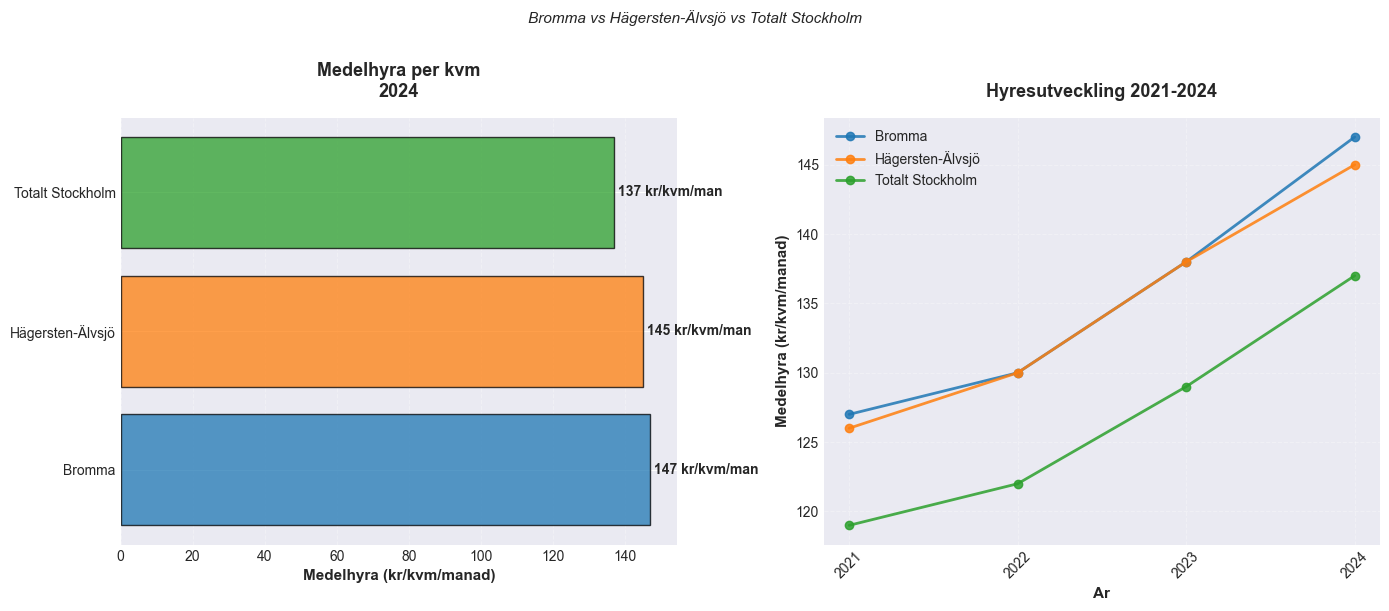

  hyror_stadsdel_2021_2024.png


In [33]:
# SNITTHYROR - Visualisering
# Vanster: stapeldiagram senaste ar
# Hoger:   tidsserie hyresutveckling

df_plot_hyra = df_hyra[df_hyra["Hyresuppg"] == "Ny månadshyra per kvm"].copy()

colors_hyra = {
    "Bromma":             "#1f77b4",
    "Hägersten-Älvsjö":  "#ff7f0e",
    "Totalt Stockholm":   "#2ca02c"
}

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

senaste_hyra = df_plot_hyra[df_plot_hyra["Tid"] == senaste_ar_hyra].copy()
ax1.barh(
    senaste_hyra["Stadsdel"],
    senaste_hyra["Medelhyra_kvm"],
    color=[colors_hyra.get(s, "#aaa") for s in senaste_hyra["Stadsdel"]],
    alpha=0.75, edgecolor="black"
)
for i, (_, row) in enumerate(senaste_hyra.iterrows()):
    ax1.text(row["Medelhyra_kvm"] + 1, i,
             f"{row['Medelhyra_kvm']:.0f} kr/kvm/man",
             va="center", fontsize=10, fontweight="bold")
ax1.set_xlabel("Medelhyra (kr/kvm/manad)", fontsize=11, fontweight="bold")
ax1.set_title(f"Medelhyra per kvm\n{senaste_ar_hyra}", fontsize=13, fontweight="bold", pad=15)
ax1.grid(axis="x", alpha=0.3, linestyle="--")

for stadsdel, color in colors_hyra.items():
    data = df_plot_hyra[df_plot_hyra["Stadsdel"] == stadsdel].sort_values("Tid")
    if len(data) > 0:
        ax2.plot(data["Tid"], data["Medelhyra_kvm"],
                 marker="o", linewidth=2, color=color, label=stadsdel, alpha=0.85)
ax2.set_xlabel("Ar", fontsize=11, fontweight="bold")
ax2.set_ylabel("Medelhyra (kr/kvm/manad)", fontsize=11, fontweight="bold")
ax2.set_title(f"Hyresutveckling {ar_hyra[0]}-{ar_hyra[-1]}", fontsize=13, fontweight="bold", pad=15)
ax2.legend(fontsize=10)
ax2.grid(alpha=0.3, linestyle="--")
ax2.tick_params(axis="x", rotation=45)

plt.suptitle("Bromma vs Hägersten-Älvsjö vs Totalt Stockholm",
             fontsize=11, style="italic", y=1.01)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / f"hyror_stadsdel_{ar_hyra_label}.png", dpi=300, bbox_inches="tight")
plt.show()
print(f"  hyror_stadsdel_{ar_hyra_label}.png")

---
## 8. Bostadsprisutveckling (hela Sverige)

Medelpris i tkr för tre bostadstyper: bostäder, småhus och fritidshus.
Jämför Stockholm mot rikssnittet över perioden 2021–2024.

**Geografisk nivå per bostadstyp:**

| Typ | Stockholm | Riket |
|-----|-----------|-------|
| Bostäder | Stor-Stockholm | Riket |
| Småhus (permanentbostad) | Stockholm kommun | Riket |
| Fritidshus | Stockholms län | Riket |

**OBS:** Kvadratmeterpris finns ej i SCB:s öppna prisstatistik – bara totalt medelpris i tkr.

**API:** `https://api.scb.se/OV0104/v1/doris/sv/ssd` (samma som hyrestabellen)  
**Tabeller:** FastprisBRFRegionAr, FastprisSHRegionAr, FastprisFHRegAr  
**Hämtas via POST** med JSON payload

In [35]:
# ======================================================================
# BOSTADSPRISUTVECKLING - Hämta data
# ======================================================================
# Tre separata POST-anrop mot SCB:s fastighetsprisstatistik.
# Samma API-endpoint som hyrestabellen (api.scb.se).
# Alla tre tabeller returnerar medelpris i tkr per år.

print("Hämtar bostadsprisutveckling...")

BASE_URL_PRIS = "https://api.scb.se/OV0104/v1/doris/sv/ssd"

# Filtrera mot AR-listan
ar_pris = AR

def hamta_prisdata(path, payload):
    r = requests.post(f"{BASE_URL_PRIS}/{path}", json=payload, timeout=30)
    r.raise_for_status()
    data = r.json()
    dims = data['id']
    dim_vals = [list(data['dimension'][d]['category']['label'].values()) for d in dims]
    df = pd.DataFrame(list(itertools.product(*dim_vals)), columns=dims)
    df['value'] = data['value']
    return df

# ── Bostäder: Stor-Stockholm vs Riket ──────────────────────────
df_pris_brf = hamta_prisdata(
    "BO/BO0501/BO0501C/FastprisBRFRegionAr",
    {
        "query": [
            {"code": "Region",       "selection": {"filter": "item", "values": ["00", "0010"]}},
            {"code": "ContentsCode", "selection": {"filter": "item", "values": ["BO0501R7"]}},
            {"code": "Tid",          "selection": {"filter": "item", "values": ar_pris}}
        ],
        "response": {"format": "json-stat2"}
    }
)
df_pris_brf['Typ'] = 'Bostäder (BRF)'
print(f"  Bostäder: {len(df_pris_brf)} rader")

# ── Småhus (permanentbostad): Stockholm kommun vs Riket ─────────
df_pris_smahus = hamta_prisdata(
    "BO/BO0501/BO0501B/FastprisSHRegionAr",
    {
        "query": [
            {"code": "Region",        "selection": {"filter": "item", "values": ["00", "0180"]}},
            {"code": "Fastighetstyp", "selection": {"filter": "item", "values": ["220"]}},
            {"code": "ContentsCode",  "selection": {"filter": "item", "values": ["BO0501C2"]}},
            {"code": "Tid",           "selection": {"filter": "item", "values": ar_pris}}
        ],
        "response": {"format": "json-stat2"}
    }
)
df_pris_smahus['Typ'] = 'Småhus'
print(f"  Småhus: {len(df_pris_smahus)} rader")

# ── Fritidshus: Stockholms län vs Riket ──────────────────────────
df_pris_fritid = hamta_prisdata(
    "BO/BO0501/BO0501B/FastprisFHRegAr",
    {
        "query": [
            {"code": "Region",       "selection": {"filter": "item", "values": ["00", "RIKS1"]}},
            {"code": "ContentsCode", "selection": {"filter": "item", "values": ["BO0501Q6"]}},
            {"code": "Tid",          "selection": {"filter": "item", "values": ar_pris}}
        ],
        "response": {"format": "json-stat2"}
    }
)
df_pris_fritid['Typ'] = 'Fritidshus'
print(f"  Fritidshus: {len(df_pris_fritid)} rader")

# Spara till CSV
pris_ar_label = f"{ar_pris[0]}_{ar_pris[-1]}"
pris_file = DATA_DIR / f"sverige_bostadspriser_{pris_ar_label}.csv"
df_alla_priser = pd.concat([df_pris_brf, df_pris_smahus, df_pris_fritid], ignore_index=True)
df_alla_priser.to_csv(pris_file, index=False, encoding='utf-8-sig')

print(f"\n  {pris_file.name} ({len(df_alla_priser)} rader)")
df_alla_priser

Hämtar bostadsprisutveckling...
  Bostäder: 8 rader
  Småhus: 8 rader
  Fritidshus: 8 rader

  sverige_bostadspriser_2021_2024.csv (24 rader)


,Region,ContentsCode,Tid,value,Typ,Fastighetstyp
0,Riket,Medelpris i tkr,2021,2785,Bostäder (BRF),NaN
1,Riket,Medelpris i tkr,2022,2771,Bostäder (BRF),NaN
2,Riket,Medelpris i tkr,2023,2704,Bostäder (BRF),NaN
3,Riket,Medelpris i tkr,2024,2821,Bostäder (BRF),NaN
4,Stor-Stockholm,Medelpris i tkr,2021,4088,Bostäder (BRF),NaN
5,Stor-Stockholm,Medelpris i tkr,2022,4121,Bostäder (BRF),NaN
6,Stor-Stockholm,Medelpris i tkr,2023,4037,Bostäder (BRF),NaN
7,Stor-Stockholm,Medelpris i tkr,2024,4206,Bostäder (BRF),NaN
8,Riket,"Köpeskilling, medelvärde i tkr",2021,3793,Småhus,permanentbostad (ej tomträtt)
9,Riket,"Köpeskilling, medelvärde i tkr",2022,3915,Småhus,permanentbostad (ej tomträtt)


In [36]:
# ======================================================================
# BOSTADSPRISUTVECKLING - DuckDB analys
# ======================================================================
# Jämför medelpris Stockholm mot Riket per bostadstyp och år.
# OBS: Geografisk nivå varierar per typ (se markdown ovan).

senaste_ar_pris = ar_pris[-1]

query_pris = f"""
SELECT
    Typ,
    Region,
    Tid,
    value as Medelpris_tkr
FROM df_alla_priser
ORDER BY Typ, Tid, Region
"""

df_pris_analys = duckdb.query(query_pris).to_df()

print("=" * 60)
print("BOSTADSPRISUTVECKLING - STOCKHOLM VS RIKET")
print("=" * 60)
print(df_pris_analys.to_string(index=False))
print("=" * 60)

# Skillnad Stockholm vs Riket senaste år per typ
print(f"\nSenaste år ({senaste_ar_pris}):")
for typ in ['Bostäder (BRF)', 'Småhus', 'Fritidshus']:
    df_typ = df_pris_analys[(df_pris_analys['Typ'] == typ) & (df_pris_analys['Tid'] == senaste_ar_pris)]
    if len(df_typ) == 2:
        riket = df_typ[df_typ['Region'] == 'Riket']['Medelpris_tkr'].iloc[0]
        sthlm = df_typ[df_typ['Region'] != 'Riket']['Medelpris_tkr'].iloc[0]
        sthlm_region = df_typ[df_typ['Region'] != 'Riket']['Region'].iloc[0]
        print(f"  {typ}: {sthlm_region} {sthlm:,.0f} tkr vs Riket {riket:,.0f} tkr ({sthlm/riket:.1f}x)")

BOSTADSPRISUTVECKLING - STOCKHOLM VS RIKET
           Typ         Region  Tid  Medelpris_tkr
Bostäder (BRF)          Riket 2021           2785
Bostäder (BRF) Stor-Stockholm 2021           4088
Bostäder (BRF)          Riket 2022           2771
Bostäder (BRF) Stor-Stockholm 2022           4121
Bostäder (BRF)          Riket 2023           2704
Bostäder (BRF) Stor-Stockholm 2023           4037
Bostäder (BRF)          Riket 2024           2821
Bostäder (BRF) Stor-Stockholm 2024           4206
    Fritidshus          Riket 2021           2441
    Fritidshus Stockholms län 2021           4750
    Fritidshus          Riket 2022           2398
    Fritidshus Stockholms län 2022           4446
    Fritidshus          Riket 2023           2276
    Fritidshus Stockholms län 2023           4321
    Fritidshus          Riket 2024           2463
    Fritidshus Stockholms län 2024           4495
        Småhus          Riket 2021           3793
        Småhus      Stockholm 2021           8598
       

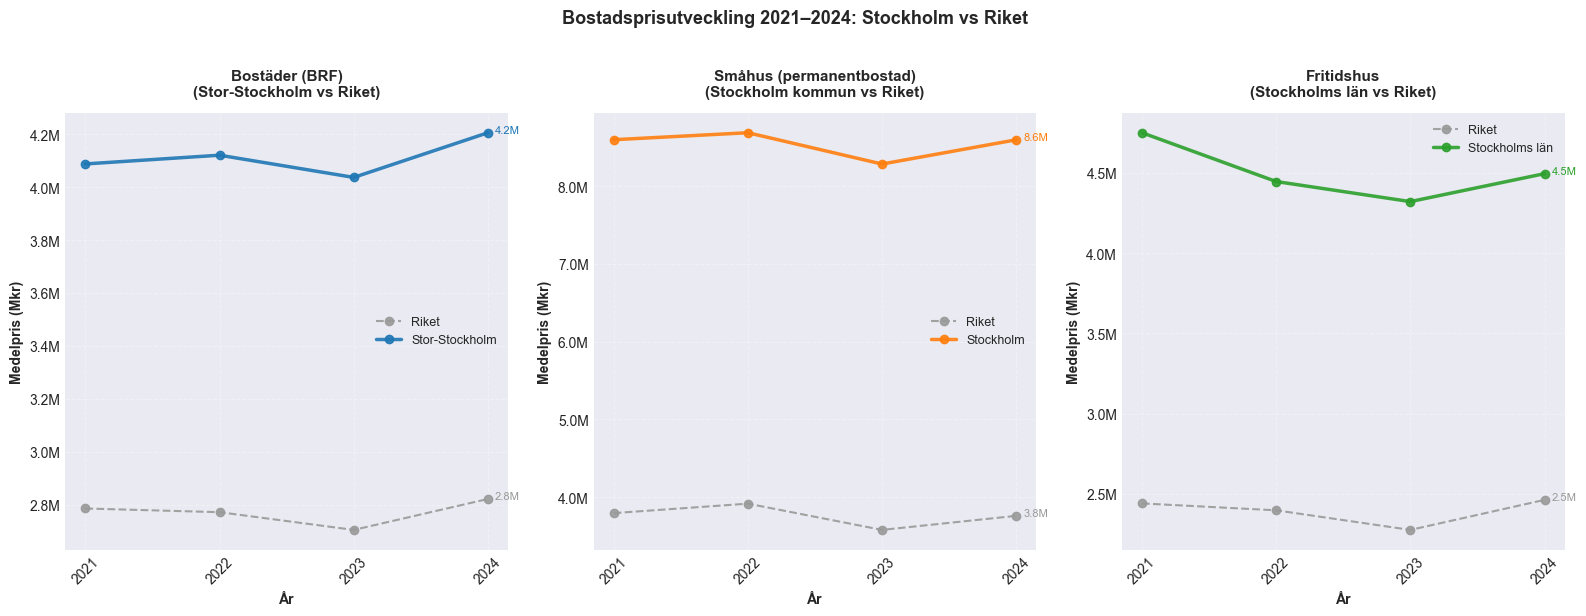

  bostadspriser_2021_2024.png


In [37]:
# ======================================================================
# BOSTADSPRISUTVECKLING - Visualisering
# ======================================================================
# Tre separata grafer: en per bostadstyp.
# Varje graf visar Stockholm (eller län) vs Riket över tid.

fig, axes = plt.subplots(1, 3, figsize=(16, 6))

datasets = [
    (df_pris_brf,    'Bostäder (BRF)\n(Stor-Stockholm vs Riket)',         axes[0], '#1f77b4'),
    (df_pris_smahus, 'Småhus (permanentbostad)\n(Stockholm kommun vs Riket)', axes[1], '#ff7f0e'),
    (df_pris_fritid, 'Fritidshus\n(Stockholms län vs Riket)',         axes[2], '#2ca02c'),
]

for df, titel, ax, color_sthlm in datasets:
    regioner = df['Region'].unique()
    for region in regioner:
        data = df[df['Region'] == region].sort_values('Tid')
        color = color_sthlm if region != 'Riket' else '#999999'
        lw    = 2.5 if region != 'Riket' else 1.5
        ls    = '-' if region != 'Riket' else '--'
        ax.plot(data['Tid'], data['value'],
                marker='o', linewidth=lw, linestyle=ls,
                color=color, label=region, alpha=0.9)
        # Värde på sista punkten
        last = data.iloc[-1]
        ax.annotate(f"{last['value']/1000:.1f}M",
                    xy=(last['Tid'], last['value']),
                    xytext=(5, 0), textcoords='offset points',
                    fontsize=8, color=color)
    ax.set_title(titel, fontsize=11, fontweight='bold', pad=12)
    ax.set_xlabel('\u00c5r', fontsize=10, fontweight='bold')
    ax.set_ylabel('Medelpris (Mkr)', fontsize=10, fontweight='bold')
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3, linestyle='--')
    ax.tick_params(axis='x', rotation=45)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1000:.1f}M'))

plt.suptitle(f'Bostadsprisutveckling {ar_pris[0]}\u2013{ar_pris[-1]}: Stockholm vs Riket',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / f'bostadspriser_{pris_ar_label}.png', dpi=300, bbox_inches='tight')
plt.show()
print(f"  bostadspriser_{pris_ar_label}.png")

---
## Sammanfattning

Översikt över all data som hämtats och skapats av notebooken.

In [38]:
print("\n" + "="*60)
print("SAMMANFATTNING")
print("="*60)

print(f"\nRAW DATA (med all detalj):")
print(f"   Folkmängd: {len(df_folkm)} rader ({len(regso_folkm)} områden x {len(aldersgrupper)} åldersgrupper x {len(ar_folkm)} år [{ar_folkm_label}])")
print(f"   Hushåll:   {len(df_hushall)} rader ({len(regso_hushall)} områden x {len(hushall_cats)} typer x {len(ar_hushall)} år [{ar_hushall_label}])")
print(f"   Boende:    {len(df_boende)} rader ({len(regso_boende)} områden x {len(boende_cats)} former x {len(ar_boende)} år)")
print(f"   OBS: Boende kortare tidserie - TAB6638 har bara {ar_boende}")

print(f"\nAGGREGERAD DATA (snapshot {senaste_ar_regso}):")
print(f"   {len(df_aggregerad)} områden")
print(f"   {df_aggregerad['Befolkning'].sum():,.0f} invånare totalt")
print(f"   {df_aggregerad['Hushall'].sum():,.0f} hushåll totalt")
print(f"   {df_aggregerad['TotalBostader'].sum():,.0f} bostäder totalt")
print(f"   Medel {df_aggregerad['PersonerPerHushall'].mean():.2f} personer/hushåll")

print(f"\nSTADSDELMAPPNING:")
print(f"   Bromma: 19 RegSO-områden")
print(f"   Hägersten-Älvsjö: 15 RegSO-områden")
print(f"   NaN: 93 områden (andra stadsdelar i Stockholm)")

print(f"\nFILER SKAPADE (alla med kolumnen 'stadsdelsomrade'):")
print(f"   stockholm_folkm_regso_{ar_folkm_label}.csv")
print(f"   stockholm_hushall_regso_{ar_hushall_label}.csv")
print(f"   stockholm_boende_regso_{ar_boende[0] if len(ar_boende) == 1 else ar_boende_label}.csv")
print(f"   stockholm_aggregerad_{senaste_ar_regso}.csv")
print(f"   stockholm_socioekonomiskt_{senaste_ar_socio}.csv")
print(f"   sverige_skattesatser_{senaste_ar}.csv")
print(f"   sverige_snittinkomst_{ar_ink_label}.csv")
print(f"   stockholm_hyror_stadsdel_{ar_hyra_label}.csv")
print(f"   sverige_bostadspriser_{pris_ar_label}.csv")

print(f"\nGRAFER SKAPADE:")
print(f"   omraden_hog_andel_barn.png")
print(f"   personer_per_hushall.png")
print(f"   korrelation_befolkning_hushall.png")
print(f"   boendeform_fordelning.png")
print(f"   aldersprofil_jamforelse.png")
print(f"   skattesatser_stockholm_vs_riket.png")
print(f"   socioekonomiskt_bromma_vs_hagersten.png")
print(f"   snittinkomst_stockholm_vs_riket_{ar_ink_label}.png")
print(f"   hyror_stadsdel_{ar_hyra_label}.png")
print(f"   bostadspriser_{pris_ar_label}.png")

print("\nKLART!")
print("="*60)


SAMMANFATTNING

RAW DATA (med all detalj):
   Folkmängd: 8636 rader (127 områden x 17 åldersgrupper x 4 år [2021_2024])
   Hushåll:   3048 rader (127 områden x 6 typer x 4 år [2021_2024])
   Boende:    508 rader (127 områden x 4 former x 1 år)
   OBS: Boende kortare tidserie - TAB6638 har bara ['2024']

AGGREGERAD DATA (snapshot 2024):
   127 områden
   995,574 invånare totalt
   485,661 hushåll totalt
   522,653 bostäder totalt
   Medel 2.16 personer/hushåll

STADSDELMAPPNING:
   Bromma: 19 RegSO-områden
   Hägersten-Älvsjö: 15 RegSO-områden
   NaN: 93 områden (andra stadsdelar i Stockholm)

FILER SKAPADE (alla med kolumnen 'stadsdelsomrade'):
   stockholm_folkm_regso_2021_2024.csv
   stockholm_hushall_regso_2021_2024.csv
   stockholm_boende_regso_2024.csv
   stockholm_aggregerad_2024.csv
   stockholm_socioekonomiskt_2024.csv
   sverige_skattesatser_2026.csv
   sverige_snittinkomst_2021_2024.csv
   stockholm_hyror_stadsdel_2021_2024.csv
   sverige_bostadspriser_2021_2024.csv

GRAFER 